In [1]:
from InSitu14CO import Site, Firn_Site, Gas, Propagator
import numpy as np
import matplotlib.pyplot as plt
import crflux.models as pm
import matplotlib.ticker as ticker
import matplotlib as mpl
import Functions_14CO as F

import os.path

from MCEq.core import MCEqRun
from MCEq import config

from tqdm import tqdm

import pandas as pd

import scipy

from scipy import stats

from scipy.io import loadmat
from scipy.interpolate import interp1d

import dynesty

In [2]:
# setup pyplot formatting

axes_style = { 'grid'      : 'True',
               'labelsize' : '14',
               'labelpad'  : '8.0'
             }
grid_style = { 'alpha'     : '0.75',
               'linestyle' : ':' }
font_style = { 'size'      : '14' }

mpl.rc('font', **font_style)
mpl.rc('axes', **axes_style)
mpl.rc('grid', **grid_style)

In [3]:
def smooth_diff(f):
    return np.concatenate(( [(f[1]-f[0])], (f[2:]-f[:-2])/2, [(f[-1]-f[-2])] ), axis=0)

def efilter(x, lambd): # x cannot grow or decay faster than an exponential rate
    
    for i in range(1,len(x)):
        if x[i]/x[i-1] > np.exp(1/lambd[i-1]):
            x[i] = x[i-1]*np.exp(1/lambd[i-1])
        elif x[i]/x[i-1] < np.exp(-1/lambd[i-1]):
            x[i] = x[i-1]*np.exp(-1/lambd[i-1])
    return x

def cum_mat_prod(A,N): # return the first N powers [0:N) of matrix A
    # A can have any shape, as long as the last 2 axes are square
    A_cum = np.ones((N,*A.shape))
    A_cum[0] = np.identity(A.shape[-1])
    for i in tqdm(range(1,N)):
        A_cum[i] = A @ A_cum[i-1]
    return A_cum

# Overview

# Setup Grids, Bins, & Site Parameters

In [4]:
lambd = 1.216e-4 # 14C differential decay rate [yr^-1]
ice_eq_file = 'Real_vs_ice_eq_depth.csv'
elev = 3233 #Elevation above sea level [m]
pressure = 65800 # air pressure (Pa)

L = [1, 7e-4] # Ice Grain Leakage Rates (yr^-1)
Acc = 0.033 # Accumulation rate (m.w.e./yr), if None takes average accumulation rate up to close-off depth
rho_co = 0.833 # density at close off depth? idk
R = 8.314472 # gas constant (J/mol K)
g = 9.82 # gravity (m/s^2)
T = -54 # Temperature (Celsius)
M_air = 28.96e-3 # molar mass of air (kg/mol)
D_0eddy = 2.55e-5 # convective diffusivity const.
H_eddy = 3 #1/e depth of convective layer
age_grid = 'DomeC_age_scale_Apr2023.csv' # sets depth-ice age conversion
tort_file = 'Firn_Model_Tortuosity_DomeC.csv' # inverse tortuosity & diff_m profiles
dt_A = 0.5
dt_D = 0.01
dz_D = 0.25
M_trace = 30e-3 # molar weight [kg/mol]
D_trace_scale = 1.25 * 0.9829926 # free air diffusivity relative to CO2, w/ “sqrt of ratio of reduced masses”

## Define Grids & Bins

In [5]:
def get_bins(x):
    # returns centers and widths of bins
    x = np.array(x)
    if x.shape[0]==2: # if first axis is length 2, takes index 0 as lower bounds, index 1 as upper bounds
        return (x[0]+x[1])/2, x[1]-x[0]
    else:
        return (x[:-1]+x[1:])/2, np.abs(np.diff(x,axis=0))

## General Ice Core Site (Taylor Glacier)

In [6]:
rho_ice_TG = 0.92
h_bins_TG = np.arange(1001)

TG_data = loadmat('matlab/MC_14CO_mod/TG_data_14CO.mat')

TG = Site(
    elev = 526, # (m) elevation listed in Figure 1 caption of Taylor Glacier study (need to confirm)
    pressure = 9.248658001389917e+04, # (Pa) pressure used in Taylor Glacier analysis "from LSD ERA reanalysis"
    z_grid = h_bins_TG/rho_ice_TG,
    h_grid = h_bins_TG,
    rho = rho_ice_TG,
    z_samp = TG_data['sample_depth_CO'][3:,0],
    CO = TG_data['CO_molec'][3:,0],
    CO_err = TG_data['CO_molec_err'][3:,0]/2.,
) # (g/cm^3) density used in Taylor Glacier analysis

## Firn Site (Dome C)

In [7]:
sample_file = 'DomeC 14CO data analysis current.xlsx'
pd_DomeC = pd.read_excel(sample_file, '14CO vs depth',
                         header = 2, index_col=0,
                         usecols=[0,1,2,3,5,6], skiprows=[3,16,21,22,23])

z_exp, CO_exp, dCO_exp = pd_DomeC.to_numpy()[:,:3].T
# separate samples into categories
i_samples = [0,3,12,len(z_exp)]
n_samples = ['Firn Sample', 'Borehole 1', 'Borehole 2']

C14_CO = Gas()
DC = Firn_Site(
    gas = C14_CO,
    z_samp = z_exp,
    dz_samp = 20,
    CO = CO_exp,
    CO_err = dCO_exp,
)

## Propagator Class

In [8]:
# Create an instance of the Propagator Class

months = [
    'January',
    #'February',
    #'March',
    #'April',
    #'May',
    #'June',
    'July',
    #'August',
    #'September',
    #'October',
    #'November',
    #'December',
]

Prop_DC = Propagator(
    site=DC,
)
density_models_DC = [('MSIS00', ('SouthPole', m)) for m in months]

Prop_DC.h

array([  0.,   1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,
        11.,  12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,
        22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,
        33.,  34.,  35.,  36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,
        44.,  45.,  46.,  47.,  48.,  49.,  50.,  51.,  52.,  53.,  54.,
        55.,  56.,  57.,  58.,  59.,  60.,  61.,  62.,  63.,  64.,  65.,
        66.,  67.,  68.,  69.,  70.,  71.,  72.,  73.,  74.,  75.,  76.,
        77.,  78.,  79.,  80.,  81.,  82.,  83.,  84.,  85.,  86.,  87.,
        88.,  89.,  90.,  91.,  92.,  93.,  94.,  95.,  96.,  97.,  98.,
        99., 100., 101., 102., 103., 104., 105., 106., 107., 108., 109.,
       110., 111., 112., 113., 114., 115., 116., 117., 118., 119., 120.,
       121., 122., 123., 124., 125., 126., 127., 128., 129., 130., 131.,
       132., 133., 134., 135., 136., 137., 138., 139., 140., 141., 142.,
       143., 144., 145., 146., 147., 148., 149., 15

In [9]:
# sets the conditions for the study at Taylor Glacier by Dyonisius et al. (https://tc.copernicus.org/articles/17/843/2023/)
Prop_TG = Propagator(
    site=TG,
) # (g/cm^3) density used in Taylor Glacier analysis
density_models_TG = [('MSIS00', ('SouthPole', m)) for m in months]

Prop_TG.h

array([   0.,    1.,    2., ...,  998.,  999., 1000.])

## Input / Output Grids

In [10]:
# Grid / Bin Ranges & Resolutions

# timespan of analysis [yrs]
t_end = 10000

# time resolutions [yrs]
# CR history time resolution
dt_CR = 20
# atmospheric time resolution
dt_atm = 10

dh_p_TG = 1
dh_p_DC = 1

dz_f_TG = 1
dz_f_DC = 1

### Production Rate Input Grids ($p: z^{\text{prod}}_p, h^{\text{prod}}_p$)

#### Taylor Glacier

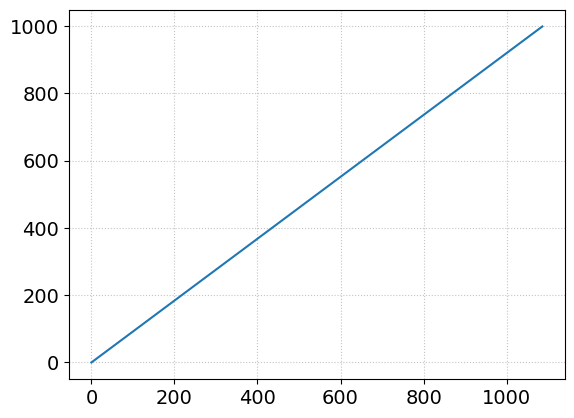

In [11]:
# Production depths [grid]

h_p_TG = np.arange(0, TG.h_grid[-1], dh_p_TG)
z_p_TG = TG.h_to_z(h_p_TG)

plt.plot(z_p_TG, h_p_TG)

#### Dome C

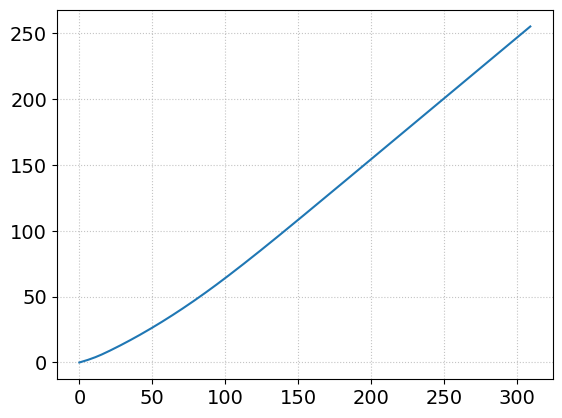

In [12]:
# Production depths [grid]

h_p_DC = np.arange(0, DC.h_grid[-1], dh_p_DC)
z_p_DC = DC.h_to_z(h_p_DC)

plt.plot(z_p_DC, h_p_DC)

### CR History Input Grid ($t: t_t^{\text{CR}}$)

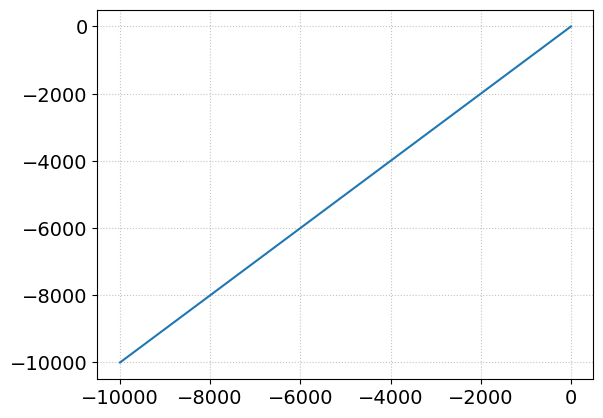

In [13]:
# Production times [grid]

t_CR = np.arange(int(t_end/dt_CR)+1)*dt_CR
t_CR = t_CR-t_CR[-1]
plt.plot(t_CR, t_CR)

### Atmospheric History Input Grid ($t_{atm}: t^{\text{atm}}_{t_{atm}}$)

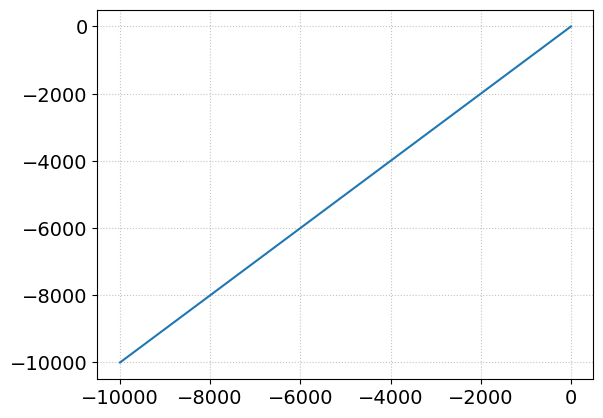

In [14]:
# Atmospheric times [grid]

t_atm = np.arange(int(t_end/dt_atm)+1)*dt_atm
t_atm = t_atm-t_atm[-1]
plt.plot(t_atm, t_atm)

### Final (Display) Depth Grid ($f: z^{\text{out}}_f, h^{\text{out}}_f$)

#### Taylor Glacier

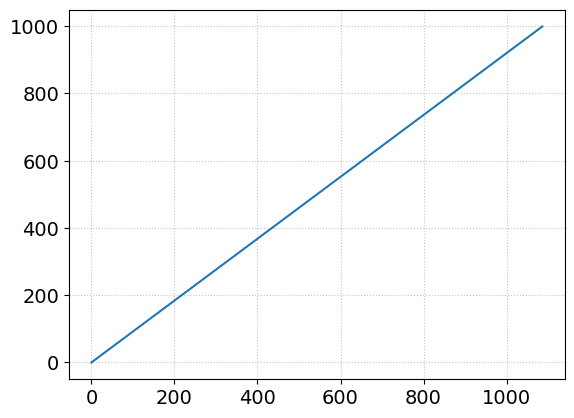

In [15]:
# final (display) depth [grid]

z_f_TG = np.arange(int(TG.z_grid[-1]/dz_f_TG)+1)*dz_f_TG
h_f_TG = TG.z_to_h(z_f_TG)

plt.plot(z_f_TG, h_f_TG)

#### Dome C

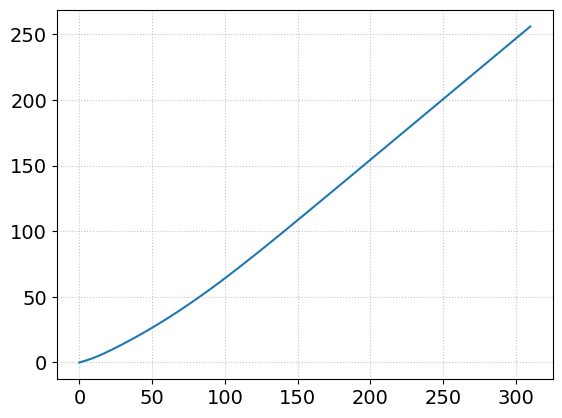

In [16]:
# final (display) depth [grid]

z_f_DC = np.arange(int(DC.z_grid[-1]/dz_f_DC)+1)*dz_f_DC
h_f_DC = DC.z_to_h(z_f_DC)

plt.plot(z_f_DC, h_f_DC)

## Interpolation Tensor ($\hat{\delta}$)

$\hat{\delta}_{i,j}$ - Interpolation tensor [unitless], interpolates a vector or tensor function ($F_j$) defined over the input grid $\vec{x}_j$ to a new output grid $\vec{y}_i$, while also functioning like a Kronecker Delta s.t. $\vec{y}_i\approx\vec{x}_j$.  If the input and output grids are identical, it is the Kronecker Delta / Identity matrix $\delta_{ij} = \hat{I}_{ij}$.

$$\hat{\delta}_{ij}(\vec{y}_i,\vec{x}_j) = \begin{cases}
\displaystyle
(\vec{y}_i\geq \vec{x}_0) - (\frac{\vec{y}_i-\vec{x}_{j}}{\vec{x}_{j+1}-\vec{x}_{j}}).\text{clip}(0,1) & j=0\\
\displaystyle
(\frac{\vec{y}_i-\vec{x}_{j-1}}{\vec{x}_j-\vec{x}_{j-1}}).\text{clip}(0,1) - (\frac{\vec{y}_i-\vec{x}_{j}}{\vec{x}_{j+1}-\vec{x}_{j}}).\text{clip}(0,1) & 0<j<\text{max}\\
\displaystyle
(\frac{\vec{y}_i-\vec{x}_{j-1}}{\vec{x}_j-\vec{x}_{j-1}}).\text{clip}(0,1) - (\vec{y}_i>\vec{x}_{\text{max}}) & j=\text{max}
\end{cases}$$

$\vec{y}_i$ - output grid

$\vec{x}_j$ - input grid

Note: Values of $\vec{y}_i$ outside the range of $\vec{x}_j$ interpolate to zero ($F_i = 0$).  To set the value below or above the bounds of $\vec{x}$ equal to the boundary value, remove the ($\vec{y}_i\geq \vec{x}_0$) or ($\vec{y}_i>\vec{x}_{\text{max}}$) term respectively.

To make an edge decrease linearly to 0 beyond the boundaries of $\vec{x}$, append an extra value at the start or end of the input vector $\vec{x}$, calculate the matrix, then remove the corresponding column from the matrix.

In [17]:
def interp_mat(out, grid_in, left=False, right=False): # interpolates from grid_in to out
    # input arrays must have broadcastable shape
    # grid's primary index should be along axis -1
    
    # slope from 0 to 1 as x passes from lower to upper bound
    slope = ((out[...,:-1 if out.shape[-1]>1 else None]-grid_in[...,:-1])/np.diff(grid_in,axis=-1)).clip(0,1)
    return np.concatenate(
        [(1-left)*(out[...,:1]>=grid_in[...,:1])-slope[...,:1],
         -np.diff(slope, axis=-1),
         slope[...,-1:]-(1-right)*(out[...,-1:]>grid_in[...,-1:])],
        axis=-1)

## Sample Average Tensor ($\hat{S}$)

$\hat{S}$ - sample average tensor [unitless], averages a vector or tensor function ($F_j$) defined within input bins $\vec{x}_j$ over output bins $\vec{y}_j$, with the average weighted by the bin widths.

$$\hat{S}_{ij}(\vec{y}_i,\vec{x}_j) = \frac{(\vec{y}_i^+ - \vec{x}_j^-).\text{clip}(0,\Delta \vec{x}_j) - (\vec{y}_i^- - \vec{x}_j^-).\text{clip}(0,\Delta \vec{x}_j)}{\sum_k (\vec{y}_i^+ - \vec{x}_k^-).\text{clip}(0,\Delta \vec{x}_k) - (\vec{y}_i^- - \vec{x}_k^-).\text{clip}(0,\Delta \vec{x}_k)}$$

$\vec{y}_i$ - Output bins (+ upper bound, - lower bound)

$\vec{x}_j$ - Input bins (- lower bound, $\Delta$ width)

In [18]:
def bin_average_mat(out_up, out_low, in_low, din):
    S = (out_up-in_low).clip(0,din) - (out_low-in_low).clip(0,din)
    return S/np.sum(S, axis=-1, keepdims=True)

# Input Vectors & Priors

## Production Rates ($\vec{P}$)

### Production Rates Calculation

#### Setup

In [19]:
interaction_model="SIBYLL-2.3c"

from MCEq import config
from MCEq.core import MCEqRun
import crflux.models as pm
from MCEq.geometry.density_profiles import GeneralizedTarget
config.debug_level = 0
config.enable_default_tracking = False
config.leading_process = "interactions"
config.e_min = Prop_DC.E_mu_bins[1]
config.e_max = Prop_DC.E_mu_bins[-1]
config.max_density = Prop_DC.Site.rho_ice
config.dedx_material='ice'
medium = 'ice'

target = GeneralizedTarget(len_target=100, env_density = 0.92, env_name = 'ice')

mceq = MCEqRun(
    interaction_model=interaction_model,
    theta_deg = 0,
    density_model = target,
    medium=medium,
    primary_model = (pm.GaisserHonda, None),
)

mceq_dedx = -mceq.pman[-13].dEdX*100

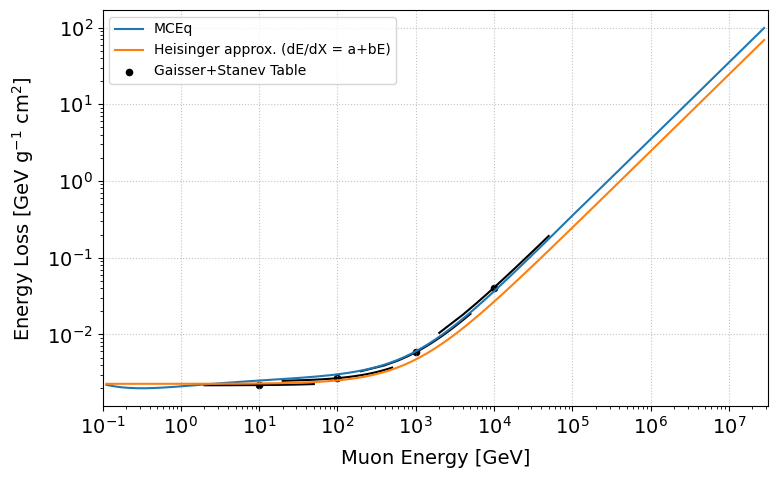

In [20]:
Prop = Prop_DC
E = Prop.E_mu

E_GS = np.array([10, 100, 1000, 10000]) # GeV
a_GS = np.array([2.17, 2.44, 2.68, 2.93])*1e-3 # GeV g^-1 cm^2
b_GS = np.array([1.66, 2.51, 3.17, 3.78])*1e-6 # g^-1 cm^2

fig, ax = plt.subplots(1,1, figsize=(8,5), tight_layout=True)

for i,e in enumerate(E_GS):
    x = (np.arange(25)+1)/5*e
    plt.plot(x, a_GS[i]+b_GS[i]*x, c='k')
plt.plot(E, mceq_dedx/100, label='MCEq')
#plt.plot(mceq._energy_grid.c, -mceq.pman[13].dEdX)
ax.plot(E, (Prop.a + Prop.b*E)/100, label='Heisinger approx. (dE/dX = a+bE)')
ax.scatter(E_GS, a_GS+b_GS*E_GS, c='k', s=20, label='Gaisser+Stanev Table')
ax.set(
    xscale='log',
    xlim=(Prop.E_mu_bins[0],Prop.E_mu_bins[-1]),
    xlabel='Muon Energy [GeV]',
    yscale='log',
    ylabel=r'Energy Loss [GeV g$^{-1}$ cm$^2$]',
)
ax.legend(fontsize=10)
#plt.title(r'Continuous Muon Energy Loss ($dE/dX$)')
plt.show()

In [21]:
alphas = np.arange(0.67,1.01,0.01)

N_alphas = len(alphas)
N_primary = 12 # number of primary models
N_atmFit = 2 # number of atmospheric muon spectrum fits
N_atm = 2 # number of atmospheric profiles
N_int = 11 # number of interaction models
N_contloss = 2 # number of continous energy loss models
N_fluxfit = 3 # number of fits to total flux (+1 for no fit)
N_H = 2 # number of pure Heisinger models

In [22]:
def setup_models(Prop, density_models):
    # setup lists of models

    # primary CRs
    primary = [(F.get_primary,
                [(pm.GlobalSplineFitBeta, None),
                 (pm.HillasGaisser2012, "H3a"),
                 (pm.HillasGaisser2012, "H4a"),
                 (pm.PolyGonato, False),
                 (pm.GaisserStanevTilav, "3-gen"),
                 (pm.GaisserStanevTilav, "4-gen"),
                 (pm.CombinedGHandHG, "H3a"),
                 (pm.ZatsepinSokolskaya, "pamela"), 
                 (pm.ZatsepinSokolskaya, "default"),
                 (pm.GaisserHonda, None),
                 (pm.Thunman, None), 
                 (pm.SimplePowerlaw27, None)
                ], 
                ['GlobalSplineFitBeta',
                 'HillasGaisser2012 H3a',
                 'HillasGaisser2012 H4a',
                 'PolyGonato',
                 'GaisserStanevTilav 3-gen',
                 'GaisserStanevTilav 4-gen',
                 'CombinedGHandHG H3a',
                 'ZatsepinSokolskaya pamela',
                 'ZatsepinSokolskaya default',
                 'GaisserHonda',
                 'Thunman',
                 'SimplePowerlaw27'
                ]),
              ]

    interaction_models = [
         "SIBYLL23CPP",
         "SIBYLL23C03",
         "SIBYLL-2.3c",
         "SIBYLL-2.3",
         "SIBYLL-2.1",
         "EPOS-LHC",
         "QGSJET-II-04",
         "QGSJETII03",
         "QGSJET01C",
         "DPMJETIII306",
         'DPMJETIII191',
    ]
    #density_models = [('CORSIKA', ('USStd', None)), ('CORSIKA',('SouthPole', 'December'))]
    #density_model = ('CORSIKA',('SouthPole', 'December'))
    #density_model = ('MSIS00', ('SouthPole', 'January'))

    # atmospheric muons
    atm = [(F.judge_nash, (), 'JN-fit'), # NOTE this fit is for SEA-LEVEL
           (F.daemonflux_atm, (), 'daemonflux'), # NOTE this fit is for SEA-LEVEL
           (F.MCEq_atm, [(i_m, d_m) for d_m in density_models for i_m in interaction_models],
            ['MCEq-atm-{}-{}'.format(i_m, d_m) for d_m in density_models for i_m in interaction_models],),
          ]
    #atm = []

    # underice muons
    ice = [#(F.Heisinger_ice, (True), 'H-ice'),
           #(F.proposal_ice, (), 'proposal'),
           #(F.Heisinger_ice, (), 'GS-ice'),
           #(F.Heisinger_ice, (False,1), 'GS-ice-linear'),
           #(F.Heisinger_ice, (False,2), 'GS-ice-loop'),
           #(F.cont_loss, [(), (Prop_DC.a+Prop_DC.b*Prop_DC.E_mu,0), (Prop_DC.a+Prop_DC.b*Prop_DC.E_mu,1), (mceq_dedx,0), (mceq_dedx,1)], ['cont-loss-GS', 'cont-loss-GS0', 'cont-loss-GS1', 'cont-loss-MCEq0', 'cont-loss-MCEq1']),
           (F.cont_loss, [(), (mceq_dedx,1)], ['contloss-GS', 'contloss-mceq']),
           #(F.MCEq_mu_ice, [(dEdX, ignore_decays) for dEdX in ['Heisinger', None] for ignore_decays in [False, True]],
            #['MCEq-mu-ice-{}-{}'.format(dEdX, ignore_decays) for dEdX in ['Heisinger', None] for ignore_decays in [False, True]],),
           #(F.MCEq_ice, [(i_m) for i_m in interaction_models], ['MCEq_ice' for i_m in interaction_models],),
           #(F.MCEq_atmice, [(i_m, d_m) for d_m in density_models for i_m in interaction_models], ['{}-{}'.format(i_m, d_m) for d_m in density_models for i_m in interaction_models],),
           (F.Heisinger_norm, [(0),()], ['fluxfit-H','fluxfit-B']),
          ]

    # 14C production rates

    prod = [
        (F.Dyonisius_prod, [(None, None, alpha) for alpha in alphas], ['alpha={:.2f}'.format(alpha) for alpha in alphas]),
        (F.Heisinger_full, [(0),()], ['Heisinger','Balco']),
    ]
    
    # Now we load our desired models into the Propagator
    Prop.set_models(primary=primary,
                    atm=atm,
                    ice=ice,
                    prod=prod)
    
    return

In [23]:
setup_models(Prop_DC, density_models_DC)
setup_models(Prop_TG, density_models_TG)

In [24]:
run_models = True
save_models = False
load_index = 3

In [25]:
tag='DomeC'
if run_models:
    Prop_DC.calculate()
    if save_models:
        Prop_DC.save_prod_to_csv(tag=tag)
    P_14C_DC = np.copy(Prop_DC.Phi['prod'])
    model_names_DC = list(Prop_DC.model_names['prod'])
else:
    P_14C_DC, model_names_DC = Prop_DC.load_prod_from_csv(tag=tag, i=load_index)

Running primary stage...
GlobalSplineFitBeta
HillasGaisser2012 H3a
HillasGaisser2012 H4a
PolyGonato
GaisserStanevTilav 3-gen
GaisserStanevTilav 4-gen
CombinedGHandHG H3a
ZatsepinSokolskaya pamela
ZatsepinSokolskaya default
GaisserHonda
Thunman
SimplePowerlaw27
primary stage complete

Running atm stage...
JN-fit
daemonflux


/mnt/c/users/walte/Documents/python-scripts/In-Situ-14C/Functions_14CO.py:134: RuntimeWarning: invalid value encountered in power
  W_K = (0.0874 * cosTH * (1- q * (y0/cosTH - 0.0874)/r_K/E_K))**(H_mu/cosTH/(r_K*E_K+90*q))


_MCEq-atm-SIBYLL23CPP-('MSIS00', ('SouthPole', 'January'))


100%|███████████████████████████████████████████████████████████████████████████████████| 10/10 [00:45<00:00,  4.57s/it]


_MCEq-atm-SIBYLL23C03-('MSIS00', ('SouthPole', 'January'))


...

atm stage complete

Running ice stage...
_contloss-GS


  0%|                                                                                            | 0/10 [00:00<?, ?it/s]/mnt/c/users/walte/Documents/python-scripts/In-Situ-14C/Functions_14CO.py:429: RuntimeWarning: divide by zero encountered in log
  return np.nan_to_num(np.exp(interp1d(np.log(x_grid), np.log(y_grid), axis=axis, bounds_error=False, assume_sorted=True)(np.log(x))))
/home/wcook/.local/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: invalid value encountered in subtract
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/home/wcook/.local/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:482: RuntimeWarning: invalid value encountered in add
  y_new = slope*(x_new - x_lo)[:, None] + y_lo
100%|███████████████████████████████████████████████████████████████████████████████████| 10/10 [00:01<00:00,  6.29it/s]


_contloss-mceq


100%|███████████████████████████████████████████████████████████████████████████████████| 10/10 [00:01<00:00,  6.02it/s]


_fluxfit-H
_fluxfit-B
ice stage complete

Running prod stage...
_alpha=0.67
_alpha=0.68
_alpha=0.69
_alpha=0.70
_alpha=0.71
_alpha=0.72
_alpha=0.73
_alpha=0.74
_alpha=0.75
_alpha=0.76
_alpha=0.77
_alpha=0.78
_alpha=0.79
_alpha=0.80
_alpha=0.81
_alpha=0.82
_alpha=0.83
_alpha=0.84
_alpha=0.85
_alpha=0.86
_alpha=0.87
_alpha=0.88
_alpha=0.89
_alpha=0.90
_alpha=0.91
_alpha=0.92
_alpha=0.93
_alpha=0.94
_alpha=0.95
_alpha=0.96
_alpha=0.97
_alpha=0.98
_alpha=0.99
_alpha=1.00
Heisinger
Balco
prod stage complete



In [26]:
tag='TaylorGlacier'
if run_models:
    Prop_TG.calculate()
    if save_models:
        Prop_TG.save_prod_to_csv(tag=tag)
    P_14C_TG = np.copy(Prop_TG.Phi['prod'])
    model_names_TG = list(Prop_DC.model_names['prod'])
else:
    P_14C_TG, model_names_TG = Prop_TG.load_prod_from_csv(tag=tag, i=load_index)

Running primary stage...
GlobalSplineFitBeta
HillasGaisser2012 H3a
HillasGaisser2012 H4a
PolyGonato
GaisserStanevTilav 3-gen
GaisserStanevTilav 4-gen
CombinedGHandHG H3a
ZatsepinSokolskaya pamela
ZatsepinSokolskaya default
GaisserHonda
Thunman
SimplePowerlaw27
primary stage complete

Running atm stage...
JN-fit
daemonflux
_MCEq-atm-SIBYLL23CPP-('MSIS00', ('SouthPole', 'January'))


100%|███████████████████████████████████████████████████████████████████████████████████| 10/10 [00:51<00:00,  5.13s/it]


_MCEq-atm-SIBYLL23C03-('MSIS00', ('SouthPole', 'January'))


100%|███████████████████████████████████████████████████████████████████████████████████| 10/10 [01:45<00:00, 10.56s/it]


_MCEq-atm-SIBYLL-2.3c-('MSIS00', ('SouthPole', 'January'))


...

_MCEq-atm-DPMJETIII306-('MSIS00', ('SouthPole', 'January'))


100%|███████████████████████████████████████████████████████████████████████████████████| 10/10 [00:46<00:00,  4.69s/it]


_MCEq-atm-DPMJETIII191-('MSIS00', ('SouthPole', 'January'))


 70%|██████████████████████████████████████████████████████████▊                         | 7/10 [00:52<00:22,  7.46s/it]


KeyboardInterrupt: 

In [ ]:
P_14C = np.concatenate((P_14C_DC, P_14C_TG), axis=-1)
model_names = model_names_DC

#### Primary CR Spectrum

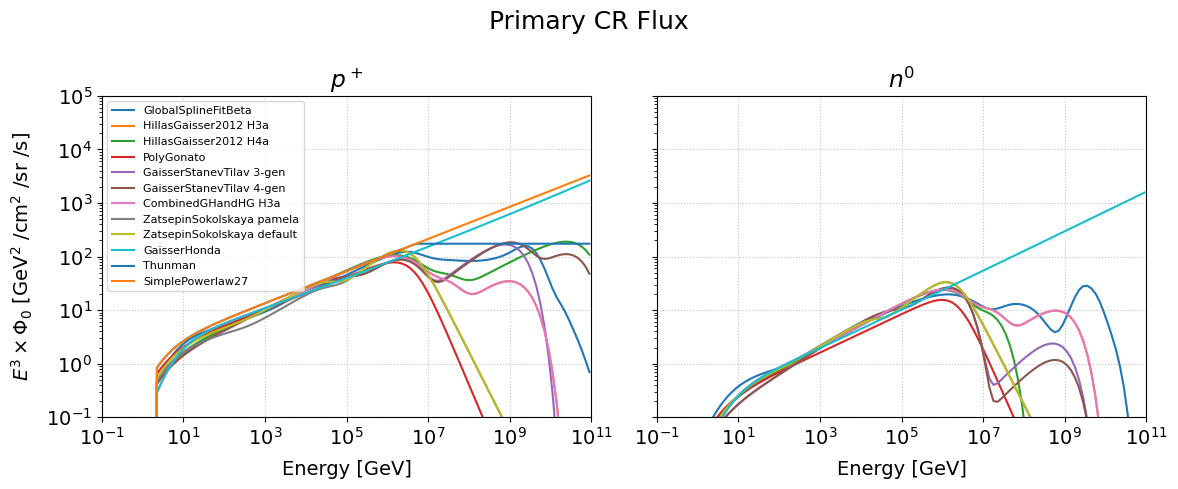

In [33]:
# plot primary flux
Epow = 3

Prop=Prop_DC # It shouldn't matter if it's Dome C or Taylor Glacier

if len(Prop.Phi['primary'])>0:
    fig, (ax1,ax2) = plt.subplots(1,2, figsize=(12,5), tight_layout=True, sharey=True, sharex=True)
    for i,p in enumerate(Prop.Phi['primary']):
        ax1.plot(Prop.E, p[0]*Prop.E**Epow, label=Prop.model_names['primary'][i])
        ax2.plot(Prop.E, p[1]*Prop.E**Epow)
    ax1.set(xlim = (Prop.E_bins[0], Prop.E_bins[-1]),
           xlabel = 'Energy [GeV]',
           xscale = 'log',
           ylabel = r'$E^{} \times \Phi_0$ [GeV$^{}$ /cm$^2$ /sr /s]'.format(Epow, Epow-1),
           ylim = (1e-1, 1e+5),
           yscale = 'log',
           title = r'$p^+$',
          )
    ax1.legend(fontsize=8)
    ax2.set(xlim = (Prop.E_bins[0], Prop.E_bins[-1]),
           xlabel = 'Energy [GeV]',
           xscale = 'log',
           #yscale = 'log',
           title = r'$n^0$',
          )
    plt.suptitle('Primary CR Flux', size=18)
    plt.show()

#### Atmospheric Muon Spectrum

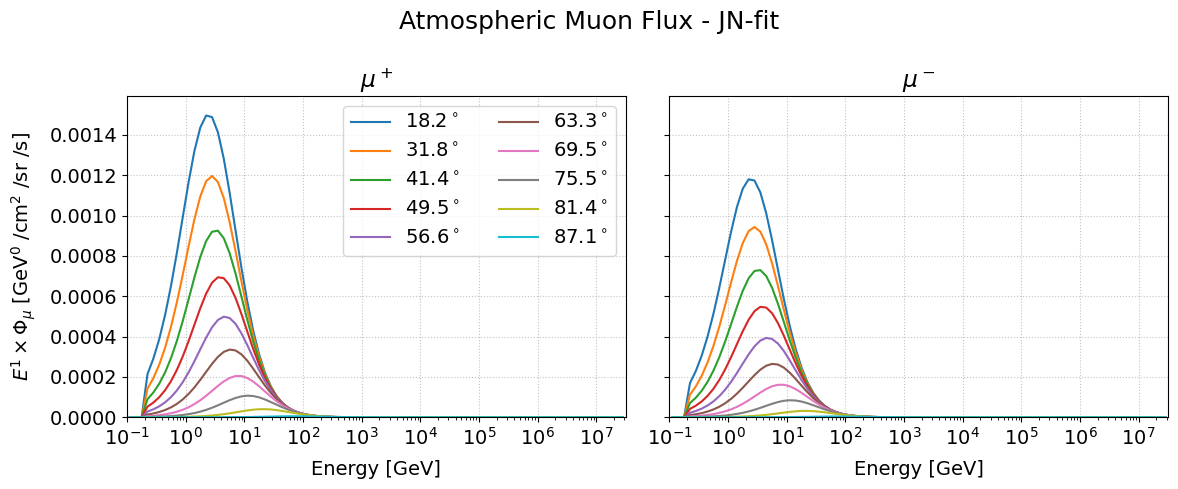

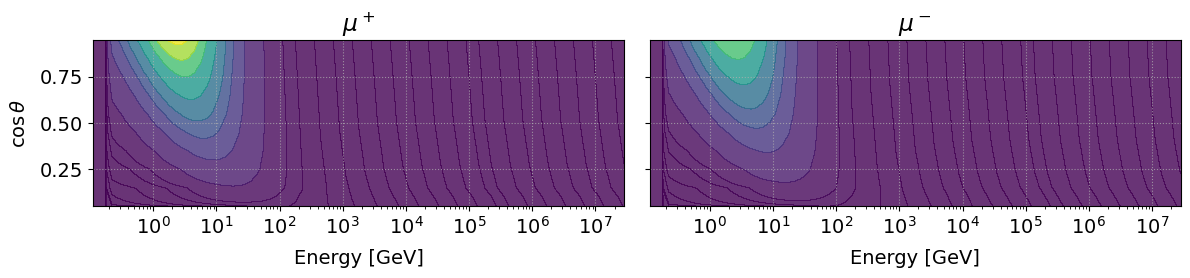

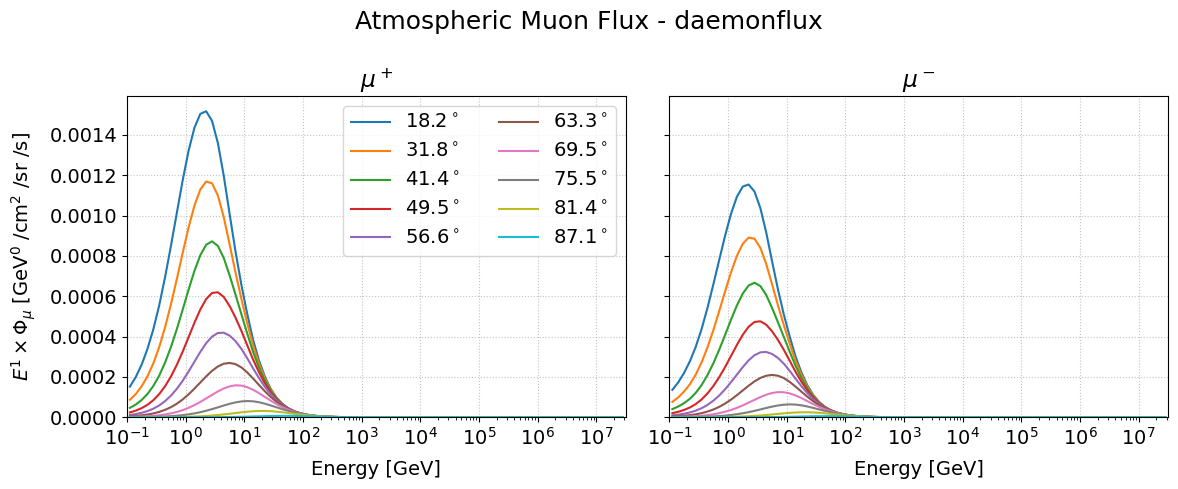

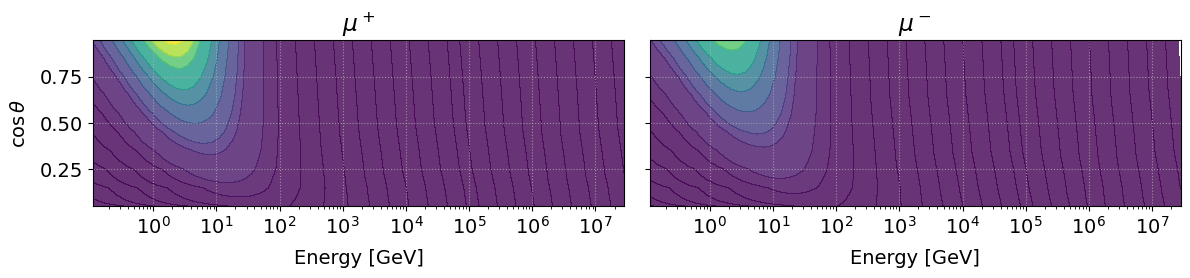

In [31]:
# Plot atmospheric muon spectra
Epow = 1

Prop=Prop_DC

if len(Prop.Phi['atm'])>0 and len(Prop.Phi['atm'])<100:
    for j in range(len(Prop.Phi['atm'])):
        fig, (ax1,ax2) = plt.subplots(1,2, figsize=(12,5), tight_layout=True, sharex = True, sharey=True)
        for i,cth in enumerate(Prop.cosTH):
            ax1.plot(Prop.E_mu, Prop.Phi['atm'][j,i,0]*Prop.E_mu**Epow, label=r'{:.1f}$^\circ$'.format(np.arccos(cth)*180/np.pi))
            ax2.plot(Prop.E_mu, Prop.Phi['atm'][j,i,1]*Prop.E_mu**Epow)
        ax1.set(xlim = (Prop.E_mu_bins[0], Prop.E_mu_bins[-1]),
                xscale = 'log',
                xlabel = 'Energy [GeV]',
                title = r'$\mu^+$',
                ylim = (np.min(Prop.Phi['atm']*Prop.E_mu**Epow), np.max(Prop.Phi['atm']*Prop.E_mu**Epow)*1.05),
                #yscale = 'log',
                ylabel = r'$E^{} \times \Phi_\mu$ [GeV$^{}$ /cm$^2$ /sr /s]'.format(Epow, Epow-1)
              )
        ax1.legend(ncol=2)
        ax2.set(xlim = (Prop.E_mu_bins[0], Prop.E_mu_bins[-1]),
                xscale = 'log',
                xlabel = 'Energy [GeV]',
                title = r'$\mu^-$',
              )
        plt.suptitle('Atmospheric Muon Flux - {}'.format(Prop.model_names['atm'][j]), size=18)
        plt.show()

        #fig, (ax1,ax2) = plt.subplots(1,2, figsize=(12,3), tight_layout=True, sharex=True, sharey=True)
        #ax1.pcolormesh(Prop.E_mu_bins, Prop.cosTH_bins, Prop.Phi_atm[j,0,:,0]*Prop.E_mu**Epow,
                       #norm = mpl.colors.PowerNorm(gamma=0.2))
        #ax2.pcolormesh(Prop.E_mu_bins, Prop.cosTH_bins, Prop.Phi_atm[j,0,:,1]*Prop.E_mu**Epow,
                       #norm = mpl.colors.PowerNorm(gamma=0.2))
        #ax1.set(xscale = 'log',
                #xlabel = 'Energy [GeV]',
                #ylabel = r'$\cos\theta$',
                #title = r'$\mu^+$',
              #)
        #ax2.set(xscale = 'log',
                #xlabel = 'Energy [GeV]',
                #title = r'$\mu^-$',
              #)
        #plt.show()


        fig, (ax1,ax2) = plt.subplots(1,2, figsize=(12,3), tight_layout=True, sharex=True, sharey=True)

        N_levels = 30
        levels = np.unique(np.sort(Prop.Phi['atm'][j,0,0]*Prop.E_mu**Epow)[np.linspace(0,len(Prop.E_mu)-1,N_levels, dtype=int)])
        #levels = np.linspace(np.min(Prop.Phi_atm[j,0]*Prop.E_mu**Epow), np.max(Prop.Phi_atm[j,0]*Prop.E_mu**Epow), N_levels)

        cf1 = ax1.contourf(Prop.E_mu, Prop.cosTH, Prop.Phi['atm'][j,:,0]*Prop.E_mu**Epow,
                       levels=levels, alpha=0.8)
        cf2 = ax2.contourf(Prop.E_mu, Prop.cosTH, Prop.Phi['atm'][j,:,1]*Prop.E_mu**Epow,
                       levels=levels, alpha=0.8)
        ax1.set(xscale = 'log',
                xlabel = 'Energy [GeV]',
                ylabel = r'$\cos\theta$',
                title = r'$\mu^+$',
              )
        ax2.set(xscale = 'log',
                xlabel = 'Energy [GeV]',
                title = r'$\mu^-$',
              )
        #fig.colorbar(cf1)
        #fig.colorbar(cf2)
        plt.show()

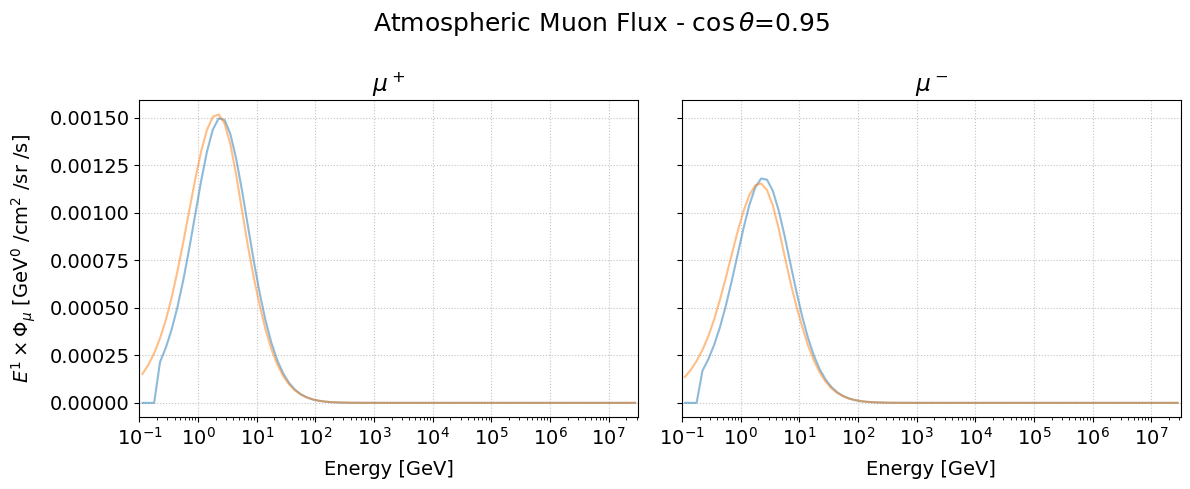

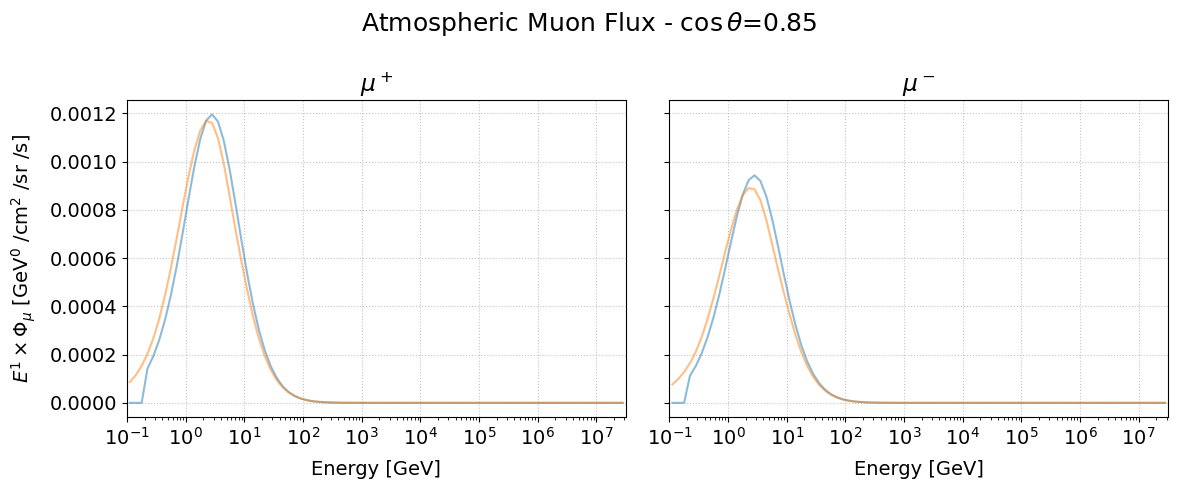

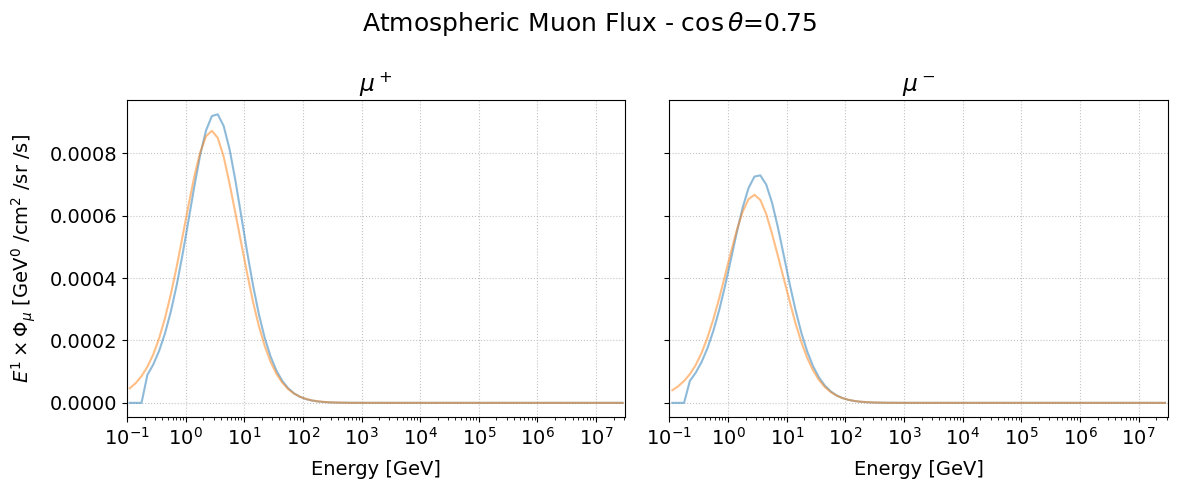

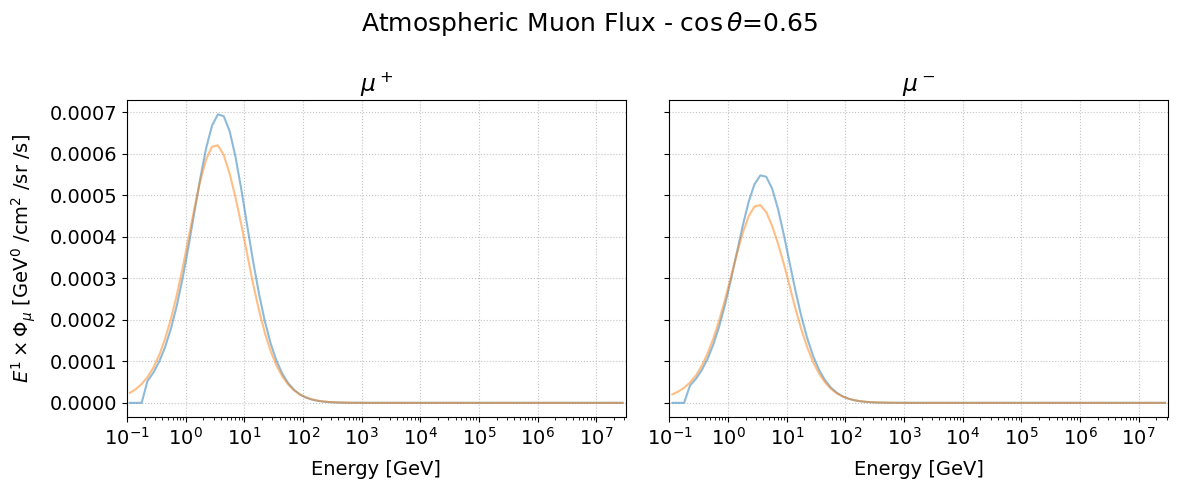

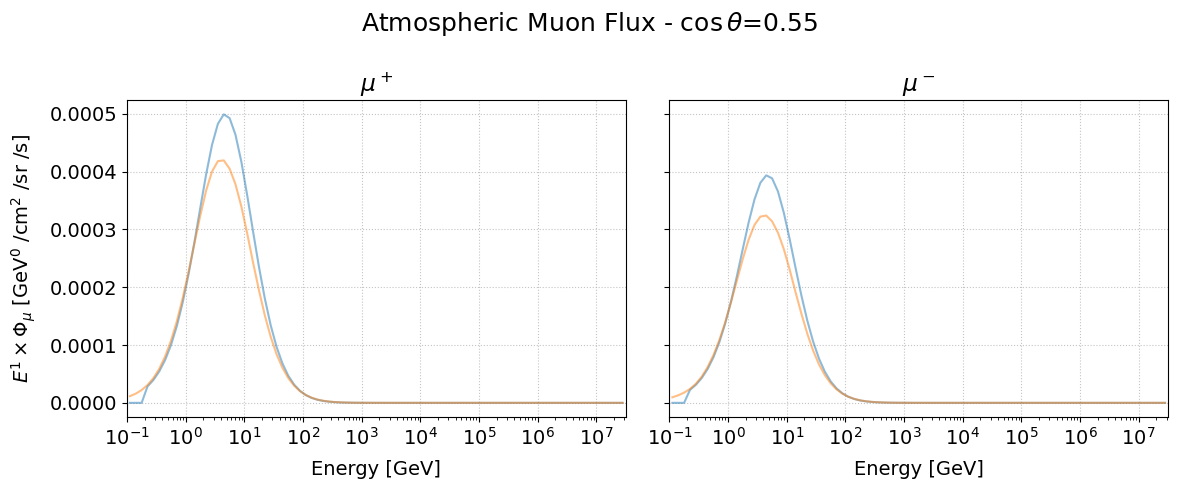

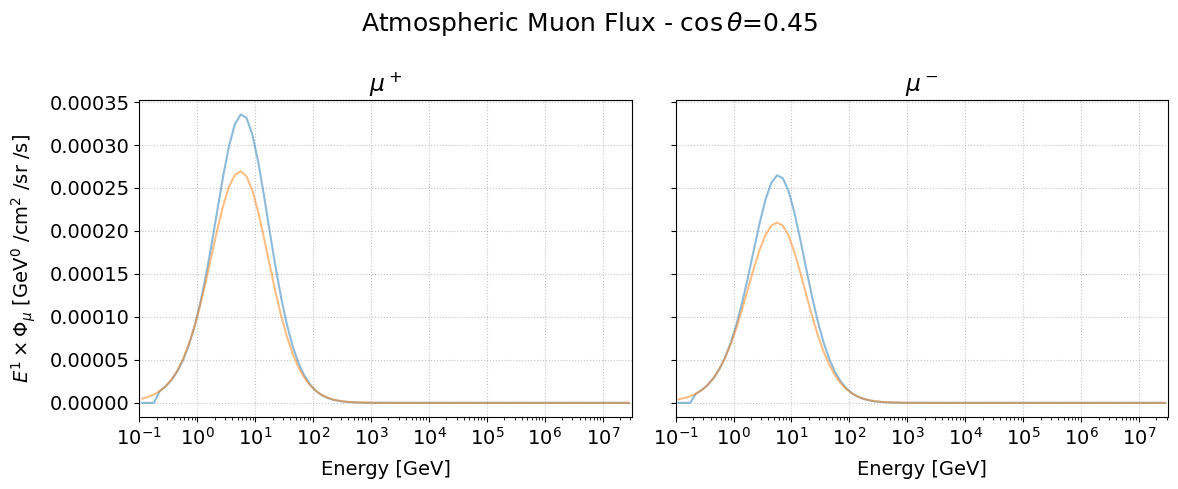

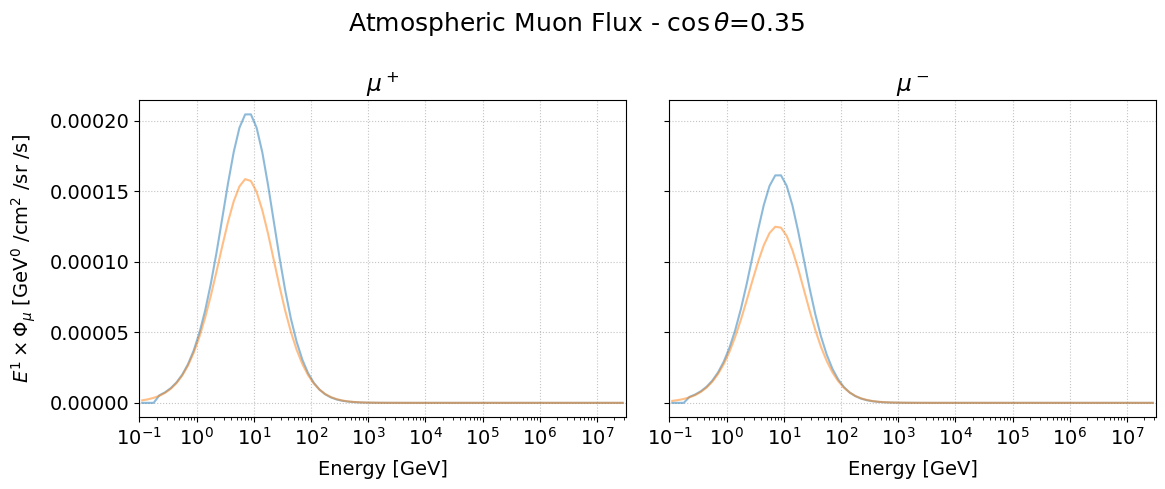

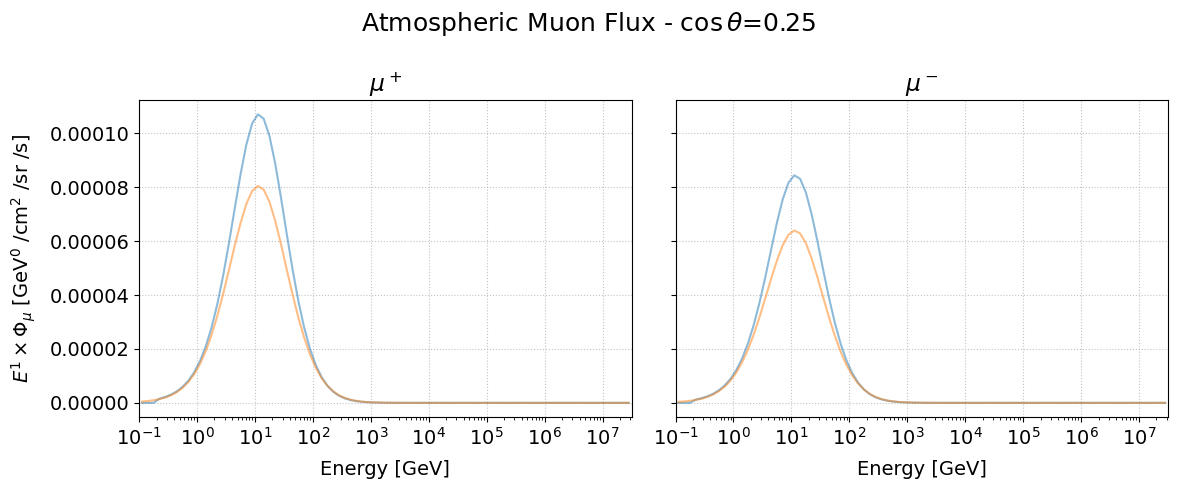

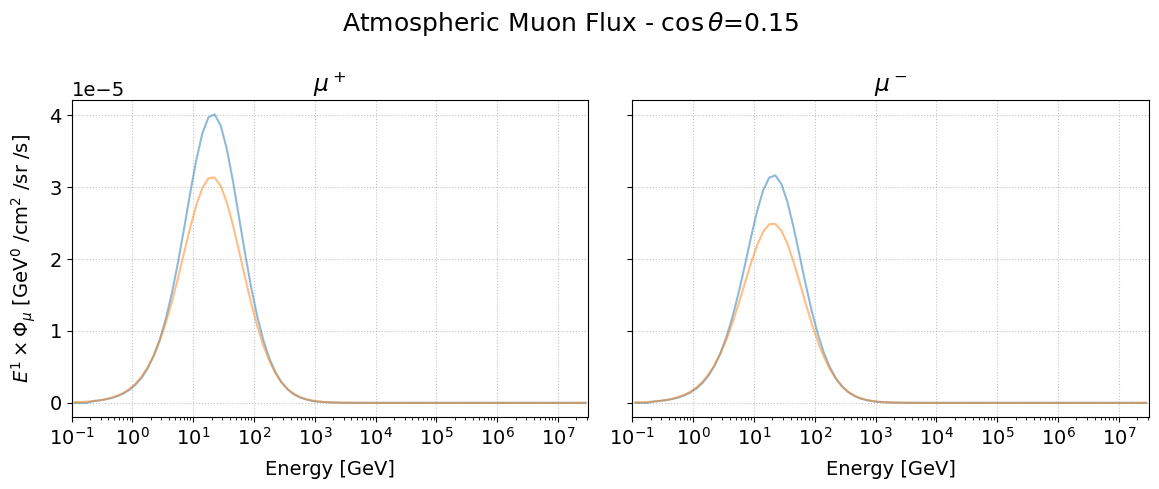

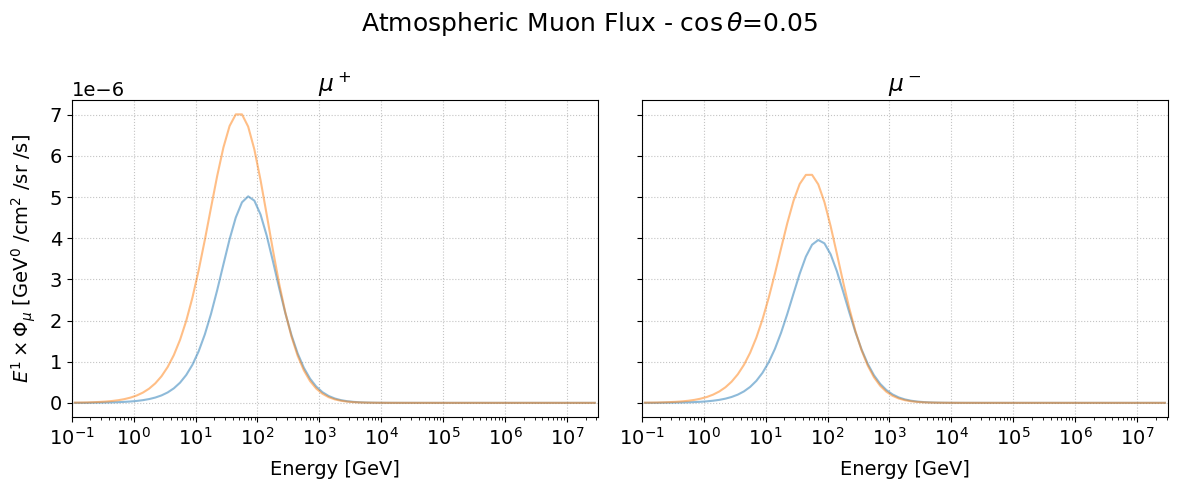

In [32]:
# Plot atmospheric muon spectra
Epow = 1

Prop=Prop_DC

if len(Prop.Phi['atm'])>0:
    for j,cth in enumerate(Prop.cosTH):
        fig, (ax1,ax2) = plt.subplots(1,2, figsize=(12,5), tight_layout=True, sharex = True, sharey=True)
        for i,p in enumerate(Prop.Phi['atm']):
            ax1.plot(Prop.E_mu, p[j,0]*Prop.E_mu**Epow, label=Prop.model_names['atm'][i], alpha=0.5)
            ax2.plot(Prop.E_mu, p[j,1]*Prop.E_mu**Epow, alpha=0.5)
        ax1.set(xlim = (Prop.E_mu_bins[0], Prop.E_mu_bins[-1]),
                xscale = 'log',
                xlabel = 'Energy [GeV]',
                title = r'$\mu^+$',
                #ylim = (np.min(Prop.Phi['atm']*Prop.E_mu**Epow), np.max(Prop.Phi['atm']*Prop.E_mu**Epow)*1.05),
                #yscale = 'log',
                ylabel = r'$E^{} \times \Phi_\mu$ [GeV$^{}$ /cm$^2$ /sr /s]'.format(Epow, Epow-1)
              )
        #ax1.legend(ncol=2)
        ax2.set(xlim = (Prop.E_mu_bins[0], Prop.E_mu_bins[-1]),
                xscale = 'log',
                xlabel = 'Energy [GeV]',
                title = r'$\mu^-$',
              )
        plt.suptitle(r'Atmospheric Muon Flux - $\cos\theta$='+'{:.2f}'.format(cth), size=18)
        plt.show()

#### Underground Muon Spectrum

In [33]:
# Plot underice muon spectra

Epow = 1

Prop = Prop_DC

if len(Prop.Phi['ice'])>0 and len(Prop.Phi['ice'])<100:
    for j in range(len(Prop.Phi['ice'])):
        fig, (ax1,ax2) = plt.subplots(1,2, figsize=(12,5), tight_layout=True, sharex = True, sharey=True)
        for z in np.arange(Prop.z_bins[0],Prop.z_bins[-1],20.):
            i = np.argmin(abs(Prop.z_bins-z))
            ax1.plot(Prop.E_mu, Prop.Phi['ice'][j,0,:,i]*Prop.E_mu**Epow, label='{:.0f} m'.format(z))
            ax2.plot(Prop.E_mu, Prop.Phi['ice'][j,1,:,i]*Prop.E_mu**Epow)
        ax1.set(xlim = (Prop.E_mu_bins[0], Prop.E_mu_bins[-1]),
                xscale = 'log',
                xlabel = 'Energy [GeV]',
                title = r'$\mu^+$',
                ylim = (np.min(Prop.Phi['ice']*np.reshape(Prop.E_mu**Epow,(1,1,-1,1)))/100,
                        np.max(Prop.Phi['ice']*np.reshape(Prop.E_mu**Epow,(1,1,-1,1)))*1.05/100),
                #yscale = 'log',
                ylabel = r'$E^{} \times \Phi_\mu$ [GeV$^{}$ /cm$^2$ /s]'.format(Epow, Epow-1)
              )
        ax1.legend(ncols=2)
        ax2.set(xlim = (Prop.E_mu_bins[0], Prop.E_mu_bins[-1]),
                xscale = 'log',
                xlabel = 'Energy [GeV]',
                title = r'$\mu^-$',
              )
        plt.suptitle('Underice Muon Flux - {}'.format(Prop.model_names['ice'][j]), size=18)
        plt.show()

        fig, (ax1,ax2) = plt.subplots(1,2, figsize=(12,6), tight_layout=True, sharex=True, sharey=True)
        #ax1.pcolormesh(Prop.E_mu_bins, Prop.z_bins, Prop.Phi_ice[j,0,0,:,:-1].T*np.reshape(Prop.E_mu**Epow, (1,-1)),
                       #norm = mpl.colors.PowerNorm(gamma=0.2))
        #ax2.pcolormesh(Prop.E_mu_bins, Prop.z_bins, Prop.Phi_ice[j,0,1,:,:-1].T*np.reshape(Prop.E_mu**Epow, (1,-1)),
                       #norm = mpl.colors.PowerNorm(gamma=0.2))

        N_levels = 30
        levels = np.sort(Prop.Phi['ice'][j,0,:,0].T*np.reshape(Prop.E_mu**Epow, (-1)))[np.linspace(0,len(Prop.E_mu)-1,N_levels, dtype=int)][1:]
        #levels = np.linspace(np.min(Prop.Phi_ice[j,0,0,:,:-1].T*np.reshape(Prop.E_mu**Epow, (1,-1))), np.max(Prop.Phi_ice[j,0,0,:,:-1].T*np.reshape(Prop.E_mu**Epow, (1,-1))), N_levels)

        cf1 = ax1.contourf(Prop.E_mu, Prop.z, Prop.Phi['ice'][j,0,:,:-1].T*np.reshape(Prop.E_mu**Epow, (1,-1)),
                       levels=levels, alpha=0.8)
        cf2 = ax2.contourf(Prop.E_mu, Prop.z, Prop.Phi['ice'][j,1,:,:-1].T*np.reshape(Prop.E_mu**Epow, (1,-1)),
                       levels=levels, alpha=0.8)
        ax1.set(xscale = 'log',
                xlabel = 'Energy [GeV]',
                ylabel = 'Depth [m]',
                ylim = (Prop.z_bins[-1], Prop.z_bins[0]),
                title = r'$\mu^+$',
              )
        ax2.set(xscale = 'log',
                xlabel = 'Energy [GeV]',
                title = r'$\mu^-$',
              )
        plt.show()

In [34]:
contloss_plots = False

Prop=Prop_DC

if contloss_plots:
    labels = ['Analytic', 'Euler Int (log-linear dE/dX)', 'Euler Int (linear dE/dX)', 'Euler Int (log-linear dE/dX)', 'Euler Int (linear dE/dX)', 'MCEq (decays)', 'MCEq (no decays)', 'MCEq (decays)', 'MCEq (no decays)']

    if len(Prop.Phi['ice'])>0:
        fig, axes = plt.subplots(2,2, figsize=(12,8), tight_layout=True, sharex = True, sharey='row', height_ratios=[2,1])
        h_i = 200
        for j in [5,6,1,2,0]:
            axes[0,0].plot(Prop.E_mu, Prop.Phi['ice'][j,0,:,h_i]*Prop.dE_mu, label=labels[j])
            axes[1,0].plot(Prop.E_mu, Prop.Phi['ice'][j,0,:,h_i]/Prop.Phi['ice'][5,0,:,h_i]-1, label=labels[j])
        for j in [7,8,3,4]:
            axes[0,1].plot(Prop.E_mu, Prop.Phi['ice'][j,0,:,h_i]*Prop.dE_mu, label=labels[j])
            axes[1,1].plot(Prop.E_mu, Prop.Phi['ice'][j,0,:,h_i]/Prop.Phi['ice'][7,0,:,h_i]-1, label=labels[j])
        axes[0,0].set(
            #xscale='log',
            #xlabel='Energy [GeV]',
            #yscale='log',
            ylabel=r'Muon Spectrum ($\Phi_\mu(E)\,dE$) [cm$^{-2}$s$^{-1}$]',
            title='Heisinger dE/dX = a+bE',
        )
        axes[1,0].set(
            xscale='log',
            xlim=(Prop_DC.E_mu_bins[0],Prop_DC.E_mu_bins[-1]),
            xlabel='Energy [GeV]',
            #yscale='log',
            ylim=(-0.03,0.03),
            ylabel='Relative to MCEq',
        )
        axes[0,1].set(
            title='MCEq dE/dX',
        )
        axes[1,1].set(
            xlabel='Energy [GeV]',
        )
        axes[0,0].legend(fontsize=10)
        axes[0,1].legend(fontsize=10)
        #axes[1,0].legend(fontsize=10)
        #axes[1,1].legend(fontsize=10)
        plt.suptitle('{:.0f} m.w.e. Muon Energy Spectrum (Dome C)'.format(Prop.h_bins[h_i]))
        plt.show()

In [35]:
# Plot underice muon spectra

if len(Prop.Phi['ice'])>0:
    fig, (ax1,ax2) = plt.subplots(1,2, figsize=(12,5), tight_layout=True, sharex = True, sharey=True)
    for i,p in enumerate(Prop.Phi['ice']):
        ax1.plot(Prop.z, np.sum(p[0]*Prop.dE_mu.reshape((-1,1)), axis=0), alpha=0.5)
        ax2.plot(Prop.z, np.sum(p[1]*Prop.dE_mu.reshape((-1,1)), axis=0), alpha=0.5)
    ax1.plot(Prop.z, np.sum(np.mean(Prop.Phi['ice'][:,0], axis=0)*Prop.dE_mu.reshape((-1,1)), axis=0), c='k', ls='--')
    ax2.plot(Prop.z, np.sum(np.mean(Prop.Phi['ice'][:,1], axis=0)*Prop.dE_mu.reshape((-1,1)), axis=0), c='k', ls='--')
    ax1.set(#xlim = (Prop.E_mu_bins[0], Prop.E_mu_bins[-1]),
            #xscale = 'log',
            #xlabel = 'Energy [GeV]',
            title = r'$\mu^+$',
            #ylim = (np.min(Prop.Phi['ice']*np.reshape(Prop.E_mu**Epow,(1,1,-1,1))),
                    #np.max(Prop.Phi['ice']*np.reshape(Prop.E_mu**Epow,(1,1,-1,1)))*1.05),
            yscale = 'log',
            ylabel = r'$E^{} \times \Phi_\mu$ [GeV$^{}$ /cm$^2$ /s]'.format(Epow, Epow-1)
          )
    #ax1.legend(ncols=2)
    ax2.set(#xlim = (Prop.E_mu_bins[0], Prop.E_mu_bins[-1]),
            #xscale = 'log',
            #xlabel = 'Energy [GeV]',
            title = r'$\mu^-$',
          )
    #plt.suptitle('Underice Muon Flux - {}'.format(Prop.model_names['ice'][j]), size=18)
    plt.show()

In [26]:
Phi_ice = Prop_DC.Phi['ice']
Phi_ice.shape

(1596, 2, 85, 256)

In [27]:
models_ice_MCEq = np.reshape(Prop_DC.model_names['ice'], (N_fluxfit,N_contloss,-1))[0,:,N_atmFit:].reshape((N_contloss,N_atm,N_int,N_primary))
Phi_ice_MCEq = Phi_ice.reshape((N_fluxfit,N_contloss,-1,*Phi_ice.shape[1:]))[0,:,N_atmFit:].reshape((N_contloss,N_atm,N_int,N_primary,*Phi_ice.shape[1:]))
Phi_ice_MCEq.shape

(2, 2, 11, 12, 2, 85, 256)

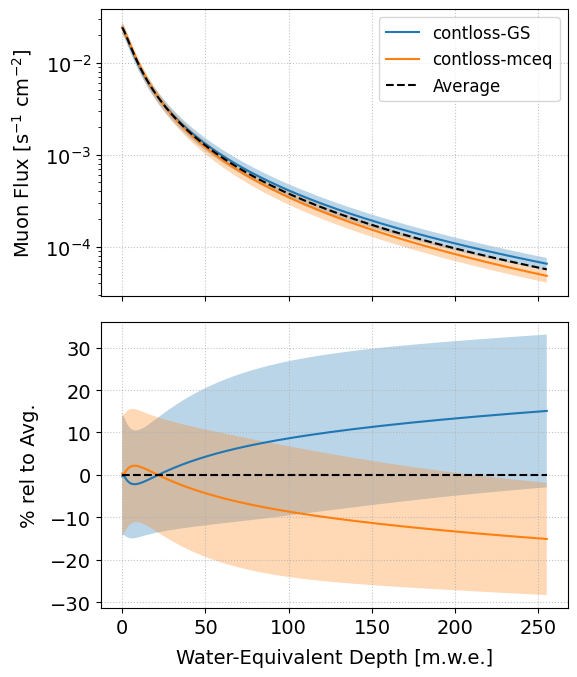

In [28]:
h = Prop_DC.h

fig, axes = plt.subplots(2,1, figsize=(6,7), tight_layout=True, sharex = True, sharey=False, height_ratios=[1,1])

rel = np.average(np.sum(Prop_DC.dE_mu @ Phi_ice_MCEq[...,:len(h)], axis=-2).reshape((-1,len(h))),axis=0)

for i,Phi in enumerate(np.swapaxes(np.sum(Phi_ice_MCEq[...,:len(h)]*Prop_DC.dE_mu[None,None,None,None,None,:,None], axis=(-3,-2)), 0, 0)):
    Phi_avg = np.average(Phi,axis=(0,1,2))
    dPhi = np.sqrt(np.average((Phi-Phi_avg[None,None,None])**2,axis=(0,1,2)))
    axes[0].fill_between(h, Phi_avg-dPhi, Phi_avg+dPhi, alpha=0.3)
    axes[0].plot(h, Phi_avg, label=models_ice_MCEq[i,0,0,0].split('_')[-1])
    axes[1].fill_between(h, ((Phi_avg-dPhi)/rel-1)*100, ((Phi_avg+dPhi)/rel-1)*100, alpha=0.3)
    axes[1].plot(h, (Phi_avg/rel-1)*100)
axes[0].plot(h, rel, ls = '--', c='k', label='Average')
axes[1].plot(h, (rel/rel-1)*100, ls='--', c='k')

axes[0].legend(fontsize=12)
axes[0].set(
    yscale='log',
    ylabel=r'Muon Flux [s$^{-1}$ cm$^{-2}$]',
)

axes[1].set(
    xlabel='Water-Equivalent Depth [m.w.e.]',
    ylabel='% rel to Avg.'
)

plt.show()

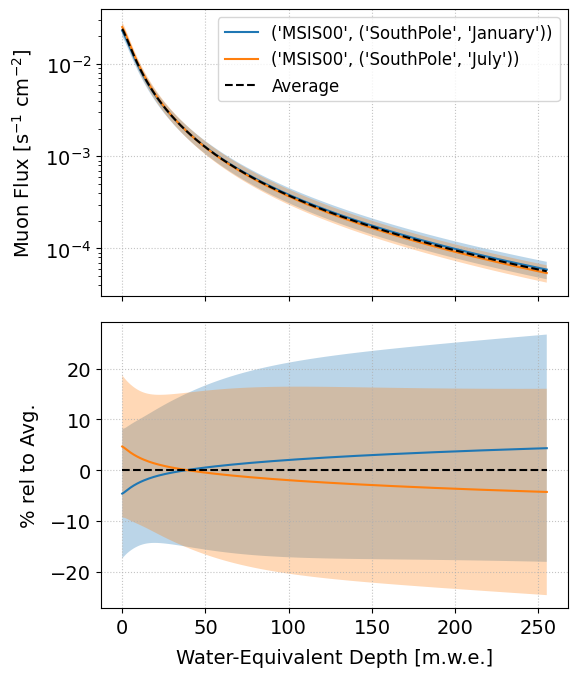

In [29]:
h = Prop_DC.h

fig, axes = plt.subplots(2,1, figsize=(6,7), tight_layout=True, sharex = True, sharey=False, height_ratios=[1,1])

rel = np.average(np.sum(Prop_DC.dE_mu @ Phi_ice_MCEq[...,:len(h)], axis=-2).reshape((-1,len(h))),axis=0)

for i,Phi in enumerate(np.swapaxes(np.sum(Phi_ice_MCEq[...,:len(h)]*Prop_DC.dE_mu[None,None,None,None,None,:,None], axis=(-3,-2)), 0, 1)):
    Phi_avg = np.average(Phi,axis=(0,1,2))
    dPhi = np.sqrt(np.average((Phi-Phi_avg[None,None,None])**2,axis=(0,1,2)))
    axes[0].fill_between(h, Phi_avg-dPhi, Phi_avg+dPhi, alpha=0.3)
    axes[0].plot(h, Phi_avg, label=models_ice_MCEq[0,i,0,0].split('_')[-2].split('-')[-1])
    axes[1].fill_between(h, ((Phi_avg-dPhi)/rel-1)*100, ((Phi_avg+dPhi)/rel-1)*100, alpha=0.3)
    axes[1].plot(h, (Phi_avg/rel-1)*100)
axes[0].plot(h, rel, ls = '--', c='k', label='Average')
axes[1].plot(h, (rel/rel-1)*100, ls='--', c='k')

axes[0].legend(fontsize=12)
axes[0].set(
    yscale='log',
    ylabel=r'Muon Flux [s$^{-1}$ cm$^{-2}$]',
)

axes[1].set(
    xlabel='Water-Equivalent Depth [m.w.e.]',
    ylabel='% rel to Avg.'
)

plt.show()

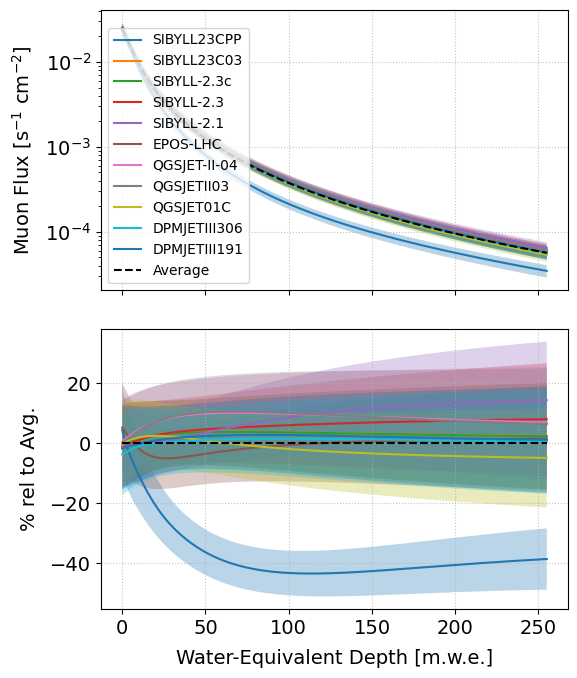

In [30]:
h = Prop_DC.h

fig, axes = plt.subplots(2,1, figsize=(6,7), tight_layout=True, sharex = True, sharey=False, height_ratios=[1,1])

rel = np.average(np.sum(Prop_DC.dE_mu @ Phi_ice_MCEq[...,:len(h)], axis=-2).reshape((-1,len(h))),axis=0)

for i,Phi in enumerate(np.swapaxes(np.sum(Phi_ice_MCEq[...,:len(h)]*Prop_DC.dE_mu[None,None,None,None,None,:,None], axis=(-3,-2)), 0, 2)):
    Phi_avg = np.average(Phi,axis=(0,1,2))
    dPhi = np.sqrt(np.average((Phi-Phi_avg[None,None,None])**2,axis=(0,1,2)))
    axes[0].fill_between(h, Phi_avg-dPhi, Phi_avg+dPhi, alpha=0.3)
    axes[0].plot(h, Phi_avg,
        label='-'.join('-'.join(models_ice_MCEq[0,0,i,0].split('_')[-2].split('-')[2:]).split('-')[:-1]))
    axes[1].fill_between(h, ((Phi_avg-dPhi)/rel-1)*100, ((Phi_avg+dPhi)/rel-1)*100, alpha=0.3)
    axes[1].plot(h, (Phi_avg/rel-1)*100)
axes[0].plot(h, rel, ls = '--', c='k', label='Average')
axes[1].plot(h, (rel/rel-1)*100, ls='--', c='k')

axes[0].legend(fontsize=10)
axes[0].set(
    yscale='log',
    ylabel=r'Muon Flux [s$^{-1}$ cm$^{-2}$]',
)

axes[1].set(
    xlabel='Water-Equivalent Depth [m.w.e.]',
    ylabel='% rel to Avg.'
)

plt.show()

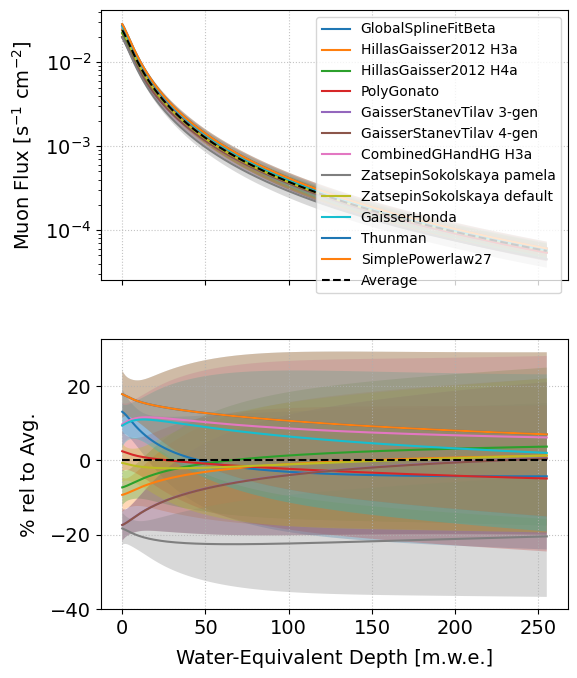

In [31]:
h = Prop_DC.h

fig, axes = plt.subplots(2,1, figsize=(6,7), tight_layout=True, sharex = True, sharey=False, height_ratios=[1,1])

rel = np.average(np.sum(Prop_DC.dE_mu @ Phi_ice_MCEq[...,:len(h)], axis=-2).reshape((-1,len(h))),axis=0)

for i,Phi in enumerate(np.swapaxes(np.sum(Phi_ice_MCEq[...,:len(h)]*Prop_DC.dE_mu[None,None,None,None,None,:,None], axis=(-3,-2)), 0, 3)):
    Phi_avg = np.average(Phi,axis=(0,1,2))
    dPhi = np.sqrt(np.average((Phi-Phi_avg[None,None,None])**2,axis=(0,1,2)))
    axes[0].fill_between(h, Phi_avg-dPhi, Phi_avg+dPhi, alpha=0.3)
    axes[0].plot(h, Phi_avg, label=models_ice_MCEq[0,0,0,i].split('_')[-3])
    axes[1].fill_between(h, ((Phi_avg-dPhi)/rel-1)*100, ((Phi_avg+dPhi)/rel-1)*100, alpha=0.3)
    axes[1].plot(h, (Phi_avg/rel-1)*100)
axes[0].plot(h, rel, ls = '--', c='k', label='Average')
axes[1].plot(h, (rel/rel-1)*100, ls='--', c='k')

axes[0].legend(fontsize=10)
axes[0].set(
    yscale='log',
    ylabel=r'Muon Flux [s$^{-1}$ cm$^{-2}$]',
)

axes[1].set(
    xlabel='Water-Equivalent Depth [m.w.e.]',
    ylabel='% rel to Avg.'
)

plt.show()

In [35]:
models_ice_AtmFit = np.reshape(Prop_DC.model_names['ice'], (N_fluxfit,N_contloss,-1))[0,:,:N_atmFit]
Phi_ice_AtmFit = Phi_ice.reshape((N_fluxfit,N_contloss,-1,*Phi_ice.shape[1:]))[0,:,:N_atmFit]
Phi_ice_AtmFit.shape

(2, 2, 2, 85, 256)

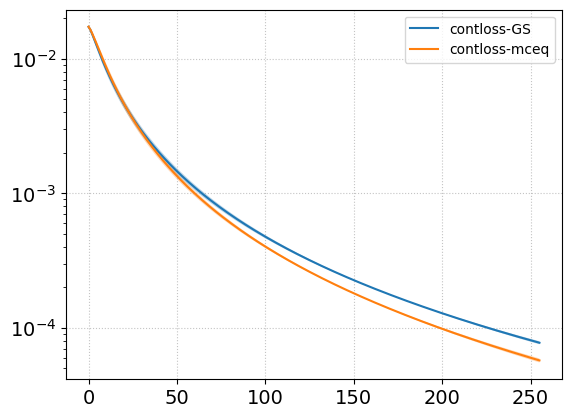

In [36]:
h = Prop_DC.h
for i,Phi in enumerate(np.swapaxes(np.sum(Phi_ice_AtmFit[...,:len(h)]*Prop_DC.dE_mu[None,None,None,:,None], axis=(-3,-2)), 0, 0)):
    Phi_avg = np.average(Phi,axis=(0))
    dPhi = np.sqrt(np.average((Phi-Phi_avg[None])**2,axis=(0)))
    plt.fill_between(h, Phi_avg-dPhi, Phi_avg+dPhi, alpha=0.3)
    plt.plot(h, Phi_avg, label=models_ice_AtmFit[i,0].split('_')[-1])
plt.legend(fontsize=10)
plt.yscale('log')

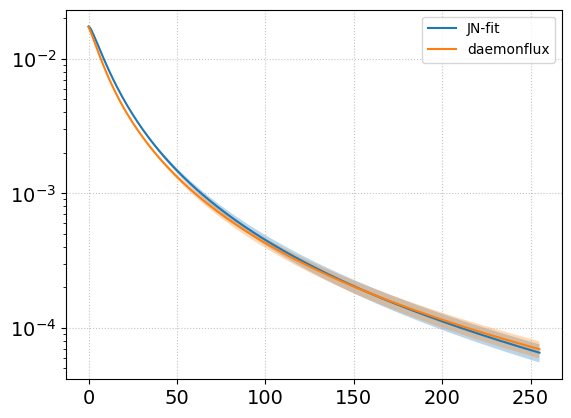

In [37]:
h = Prop_DC.h
for i,Phi in enumerate(np.swapaxes(np.sum(Phi_ice_AtmFit[...,:len(h)]*Prop_DC.dE_mu[None,None,None,:,None], axis=(-3,-2)), 0, 1)):
    Phi_avg = np.average(Phi,axis=(0))
    dPhi = np.sqrt(np.average((Phi-Phi_avg[None])**2,axis=(0)))
    plt.fill_between(h, Phi_avg-dPhi, Phi_avg+dPhi, alpha=0.3)
    plt.plot(h, Phi_avg, label=models_ice_AtmFit[0,i].split('_')[-2])
plt.legend(fontsize=10)
plt.yscale('log')

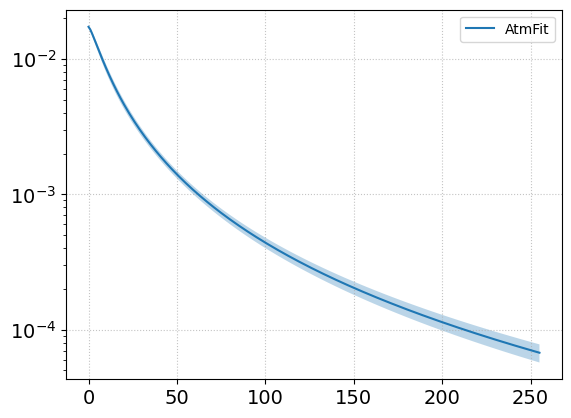

In [38]:
h = Prop_DC.h
Phi = np.sum(Phi_ice_AtmFit[...,:len(h)]*Prop_DC.dE_mu[None,None,None,:,None], axis=(-3,-2))
Phi_avg = np.average(Phi,axis=(0,1))
dPhi = np.sqrt(np.average((Phi-Phi_avg[None,None])**2,axis=(0,1)))
plt.fill_between(h, Phi_avg-dPhi, Phi_avg+dPhi, alpha=0.3)
plt.plot(h, Phi_avg, label='AtmFit')
plt.legend(fontsize=10)
plt.yscale('log')

In [40]:
models_ice_FluxFit = np.reshape(Prop_DC.model_names['ice'], (N_fluxfit,N_contloss,-1))[1:]
Phi_ice_FluxFit = Phi_ice.reshape((N_fluxfit,N_contloss,-1,*Phi_ice.shape[1:]))[1:]

Phi_ice_FluxFit.shape

(2, 2, 266, 2, 85, 256)

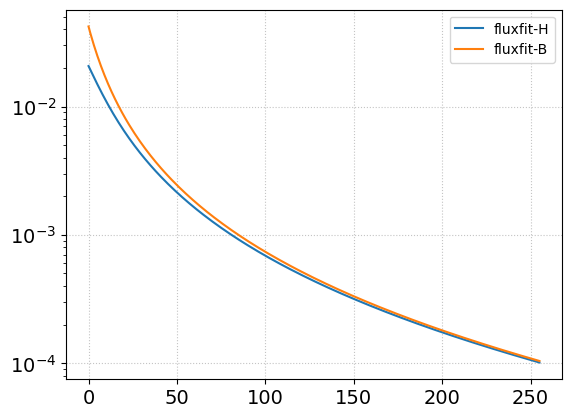

In [41]:
h = Prop_DC.h
for i,Phi in enumerate(np.swapaxes(np.sum(Phi_ice_FluxFit[...,:len(h)]*Prop_DC.dE_mu[None,None,None,None,:,None], axis=(-3,-2)), 0, 0)):
    Phi_avg = np.average(Phi,axis=(0,1))
    dPhi = np.sqrt(np.average((Phi-Phi_avg[None])**2,axis=(0,1)))
    plt.fill_between(h, Phi_avg-dPhi, Phi_avg+dPhi, alpha=0.3)
    plt.plot(h, Phi_avg, label=models_ice_FluxFit[i,0,0].split('_')[-1])
plt.legend(fontsize=10)
plt.yscale('log')

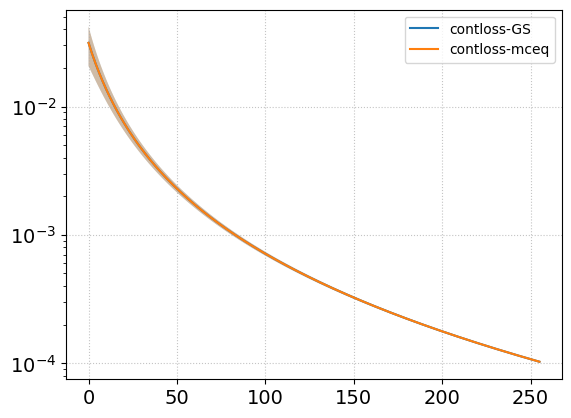

In [42]:
h = Prop_DC.h
for i,Phi in enumerate(np.swapaxes(np.sum(Phi_ice_FluxFit[...,:len(h)]*Prop_DC.dE_mu[None,None,None,None,:,None], axis=(-3,-2)), 0, 1)):
    Phi_avg = np.average(Phi,axis=(0,1))
    dPhi = np.sqrt(np.average((Phi-Phi_avg[None])**2,axis=(0,1)))
    plt.fill_between(h, Phi_avg-dPhi, Phi_avg+dPhi, alpha=0.3)
    plt.plot(h, Phi_avg, label=models_ice_FluxFit[0,i,0].split('_')[-2])
plt.legend(fontsize=10)
plt.yscale('log')

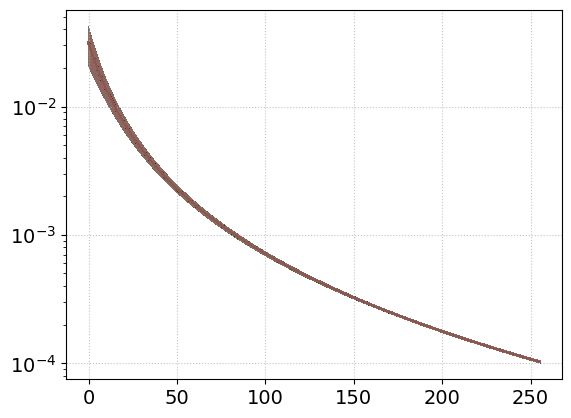

In [43]:
h = Prop_DC.h
for i,Phi in enumerate(np.swapaxes(np.sum(Phi_ice_FluxFit[...,:len(h)]*Prop_DC.dE_mu[None,None,None,None,:,None], axis=(-3,-2)), 0, 2)):
    Phi_avg = np.average(Phi,axis=(0,1))
    dPhi = np.sqrt(np.average((Phi-Phi_avg[None])**2,axis=(0,1)))
    plt.fill_between(h, Phi_avg-dPhi, Phi_avg+dPhi, alpha=0.3)
    plt.plot(h, Phi_avg)#, label=models_ice_FluxFit[0,0,i].split('_')[-2])
#plt.legend(fontsize=10)
plt.yscale('log')

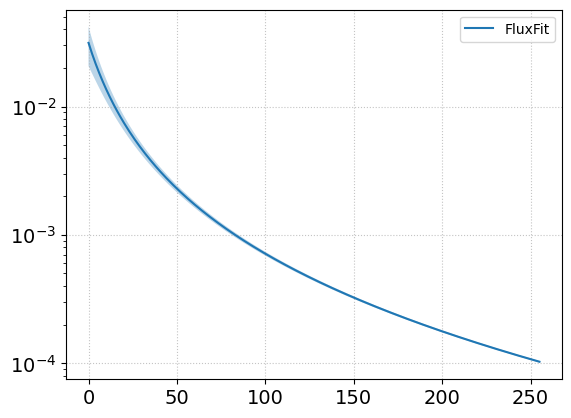

In [44]:
h = Prop_DC.h
Phi = np.sum(Phi_ice_FluxFit[...,:len(h)]*Prop_DC.dE_mu[None,None,None,None,:,None], axis=(-3,-2))
Phi_avg = np.average(Phi,axis=(0,1,2))
dPhi = np.sqrt(np.average((Phi-Phi_avg[None,None])**2,axis=(0,1,2)))
plt.fill_between(h, Phi_avg-dPhi, Phi_avg+dPhi, alpha=0.3)
plt.plot(h, Phi_avg, label='FluxFit')
plt.legend(fontsize=10)
plt.yscale('log')

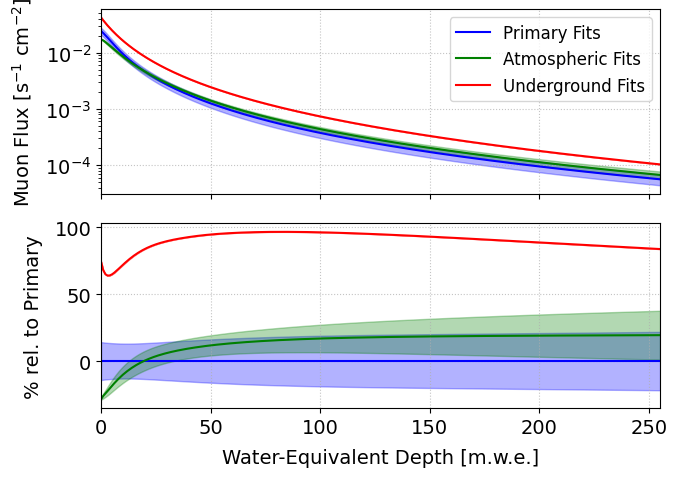

In [51]:
h = Prop_DC.h
fig, axes = plt.subplots(2,1, figsize=(7,5), tight_layout=True, sharex = True, sharey=False, height_ratios=[1,1])

rel = np.average(np.sum(Prop_DC.dE_mu @ Phi_ice_MCEq[...,:len(h)], axis=-2).reshape((-1,len(h))),axis=0)

for p,c,m in zip([Phi_ice_MCEq, Phi_ice_AtmFit, Phi_ice_FluxFit[1:]], ['b','g','r'], ['Primary', 'Atmospheric', 'Underground']):
    Phi = np.sum(Prop_DC.dE_mu @ p[...,:len(h)], axis=-2)
    Phi_avg = np.average(Phi.reshape((-1,len(h))),axis=0)
    dPhi = np.sqrt(np.average((Phi.reshape((-1,len(h)))-Phi_avg)**2,axis=0))
    axes[0].fill_between(h, Phi_avg-dPhi, Phi_avg+dPhi, color=c, alpha=0.3)
    axes[1].fill_between(h, ((Phi_avg-dPhi)/rel-1)*100, ((Phi_avg+dPhi)/rel-1)*100, color=c, alpha=0.3)
    axes[0].plot(h, Phi_avg, color=c, label='{} Fits'.format(m))
    axes[1].plot(h, (Phi_avg/rel - 1)*100, color=c)

axes[0].legend(fontsize=12)
axes[0].set(
    yscale='log',
    ylabel=r'Muon Flux [s$^{-1}$ cm$^{-2}$]',
)

axes[1].set(
    xlabel='Water-Equivalent Depth [m.w.e.]',
    xlim=(h[0], h[-1]),
    ylabel='% rel. to Primary'
)

plt.show()

#### In Situ $^{14}$CO Production Rates

In [38]:
# Plot 14C Production rates

Prop=Prop_DC

if 0<len(Prop.Phi['prod'])<100:
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,5), tight_layout=True, sharex = True, sharey=True)
    for i,p in enumerate(Prop.Phi['prod']):
        ax1.plot(Prop.z, p[0], label=Prop.model_names['prod'][i], alpha=0.5)
        ax2.plot(Prop.z, p[1], alpha=0.5)
    ax1.plot(Prop.z, np.mean(Prop.Phi['prod'][:,0], axis=0), c='k', ls='--')
    ax2.plot(Prop.z, np.mean(Prop.Phi['prod'][:,1], axis=0), c='k', ls='--')
    ax1.set(xlim = (Prop.z_bins[0], Prop.z_bins[-1]),
            xlabel = 'Depth [m]',
            title = r'$P_{\mu f}$',
            yscale = 'log',
            ylabel = r'Production Rate [/g /yr]'
          )
    #ax1.legend(fontsize=10, ncols=2)
    ax2.set(xlim = (Prop.z_bins[0], Prop.z_bins[-1]),
            #xlim = (Prop.z[0], Prop.z_bins[-1]),
            #xscale='log',
            xlabel = 'Depth [m]',
            title = r'$P_{\mu-}$',
            #yscale = 'log',
            #ylabel = r'Production Rate [/g /yr]'
          )
    plt.suptitle(r'$^{14}$C Production Rates')
    plt.show()

    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,5), tight_layout=True, sharex = True)
    for i,p in enumerate(Prop.Phi['prod']):
        ax1.plot(Prop.z, p[0]/Prop.Phi['prod'][-1,0], alpha=0.5)#, label=Prop.model_names['prod'][i])
        ax2.plot(Prop.z, p[1]/Prop.Phi['prod'][-1,1], alpha=0.5)
    ax1.plot(Prop.z, np.mean(Prop.Phi['prod'][:,0], axis=0)/Prop.Phi['prod'][-1,0], c='k', ls='--')
    ax2.plot(Prop.z, np.mean(Prop.Phi['prod'][:,1], axis=0)/Prop.Phi['prod'][-1,1], c='k', ls='--')
    ax1.set(xlim = (Prop.z_bins[0], Prop.z_bins[-1]),
            xlabel = 'Depth [m]',
            title = r'$P_{\mu f}$',
            ylabel='Ratio to {}'.format(Prop.model_names['prod'][-1]),
          )
    #ax1.legend(fontsize=10, ncols=2)
    ax2.set(xlim = (Prop.z_bins[0], Prop.z_bins[-1]),
            xlabel = 'Depth [m]',
            title = r'$P_{\mu-}$',
            #yscale = 'log',
            #ylabel = r'Production Rate [/g /yr]'
            ylabel='Ratio to {}'.format(Prop.model_names['prod'][-1]),
          )
    plt.show()

### Production Models ($i$): Averages ($\hat{P}_i$) and Uncertainties ($\Sigma^{P}_i$)

In [39]:
models_MCEq = np.reshape(model_names[:-N_H], (N_alphas,N_contloss*N_fluxfit,-1))[:,:N_contloss,N_atmFit:].reshape((N_alphas,N_contloss,N_atm,N_int,-1))
#axis0 - alpha
#axis1 - Underice Propagation Model
#axis2 - Month (Atmospheric Profile)
#axis3 - Interaction Model
#axis4 - Primary Model

P_MCEq = P_14C[:-N_H].reshape((N_alphas,N_contloss*N_fluxfit,-1,*P_14C.shape[1:]))[:,:N_contloss,N_atmFit:].reshape((N_alphas,N_contloss,N_atm,N_int,-1,*P_14C.shape[1:]))
#axis0 - alpha
#axis1 - Underice Propagation Model
#axis2 - Month (Atmospheric Profile)
#axis3 - Interaction Model
#axis4 - Primary Model
#axis5 - Production Mode
#axis6 - Production Depth
P_MCEq.shape

(34, 2, 2, 11, 12, 2, 1257)

In [40]:
# weights on MCEq models
alpha = np.array([0.75, 0.93])
dalpha = np.array([0.08, 0.07])

w_alpha = np.array([0.5,0.5]) # alpha
w_alphas = np.sum([np.exp(-((alphas-a)/dalpha[i])**2/2)/dalpha[i] * w_alpha[i] for i,a in enumerate(alpha)], axis=0)

w_ice = np.ones(models_MCEq.shape[1]) # ice propagation model
#w_ice[5:] = 0.

w_atm = np.ones(models_MCEq.shape[2]) # atmospheric profile

w_int = np.ones(models_MCEq.shape[3]) # interaction model
#w_int[:1] = 0.

w_primary = np.ones(models_MCEq.shape[4]) # primary model
#w_primary[3:] = 0.

w_MCEq = w_alphas.reshape((-1,1,1,1,1)) * w_ice.reshape((1,-1,1,1,1)) * w_atm.reshape((1,1,-1,1,1)) * w_int.reshape((1,1,1,-1,1)) * w_primary.reshape((1,1,1,1,-1))
w_MCEq /= np.sum(w_MCEq) # normalize the weights

In [41]:
models_AtmFit = np.reshape(model_names[:-N_H], (N_alphas,N_contloss*N_fluxfit,-1))[:,:N_contloss,:N_atmFit]
#axis0 - alpha
#axis1 - Underice Propagation Model
#axis2 - Atmospheric Muon Flux Fit

P_AtmFit = P_14C[:-N_H].reshape((N_alphas,N_contloss*N_fluxfit,-1,*P_14C.shape[1:]))[:,:N_contloss,:N_atmFit]
#axis0 - alpha
#axis1 - Underice Propagation Model
#axis2 - Atmospheric Muon Flux Fit
#axis3 - Production Mode
#axis4 - Depth
P_AtmFit.shape

(34, 2, 2, 2, 1257)

In [42]:
w_surf = np.ones(models_AtmFit.shape[2])

w_AtmFit = w_alphas.reshape((-1,1,1)) * w_ice.reshape((1,-1,1)) * w_surf.reshape((1,1,-1))
w_AtmFit /= np.sum(w_AtmFit)

In [43]:
models_FluxFit = np.reshape(model_names[:-N_H], (N_alphas,N_contloss*N_fluxfit,-1))[:,N_contloss:]
#axis0 - alpha
#axis1 - Underice Propagation Model
#axis2 - AtmFit / MCEq Model

P_FluxFit = P_14C[:-N_H].reshape((N_alphas,N_contloss*N_fluxfit,-1,*P_14C.shape[1:]))[:,N_contloss:]
#axis0 - alpha
#axis1 - Underice Propagation Model
#axis2 - AtmFit / MCEq Model
#axis3 - Production Mode
#axis4 - Depth
P_FluxFit.shape

(34, 4, 266, 2, 1257)

In [44]:
w_FluxFit = np.repeat(np.concatenate((w_AtmFit, w_MCEq.reshape((*w_MCEq.shape[:2],-1))), axis=-1), N_fluxfit-1, axis=1)
w_FluxFit /= np.sum(w_FluxFit)

In [45]:
models_Heisinger = np.array(model_names[-N_H:])

P_Heisinger = P_14C[-N_H:]
#axis0 - Heisinger Model
#axis1 - Production Mode
#axis2 - Depth
P_Heisinger.shape

(2, 2, 1257)

In [46]:
production_models = ['MCEq', 'AtmFit', 'FluxFit']
PM_labels = ['{}-{:.2f}'.format(m,a) for m in production_models for a in alpha]
PM_labels

['MCEq-0.75',
 'MCEq-0.93',
 'AtmFit-0.75',
 'AtmFit-0.93',
 'FluxFit-0.75',
 'FluxFit-0.93']

In [47]:
def get_P_alpha_cov(P, w, alphas, a, da):
    P_a = P[np.isclose(alphas, a)][0].reshape((-1,*P.shape[-2:]))
    w_a = w[np.isclose(alphas, a)][0].reshape((-1))
    w_a /= np.sum(w_a)
    Sigma_a = np.cov(P_a.reshape(len(P_a),-1), aweights=w_a, rowvar=False).reshape(*P_a.shape[1:],*P_a.shape[1:]).swapaxes(1,2)
    alpha_cut = (alphas<=(a+da)) * (alphas>=(a-da)) * ~np.isclose(alphas, a)
    P_range = P[alpha_cut].reshape((np.sum(alpha_cut),-1,*P.shape[-2:]))
    dP_da = np.average((P_range - P_a)/(alphas[alpha_cut]-a).reshape((-1,1,1,1)), weights=np.exp(-((alphas[alpha_cut]-a)/da)**2/2), axis=0)
    #dSigma_a = np.average(dP_da.reshape((len(w_a),-1,1)) * dP_da.reshape((len(w_a),1,-1)), weights=w_a, axis=0).reshape(*P_a.shape[1:],*P_a.shape[1:]).swapaxes(1,2)
    dSigma_a = np.einsum('aik,ajl,a->ijkl', dP_da, dP_da, w_a, optimize=True)
    
    #P_a_avg = np.average(P_a, weights=w_a, axis=0)
    P_a_cov = Sigma_a + dSigma_a * da**2
    #P_a_std = np.sqrt([np.diag(P_a_cov[0,0]), np.diag(P_a_cov[1,1])])
    
    return P_a_cov

In [48]:
alpha_i = [8,-8] # indexes of central alphas
P_avg = np.array([np.average(P[i].reshape((-1,*P.shape[-2:])), weights=w[i].reshape((-1)), axis=0) for P,w in zip([P_MCEq,P_AtmFit,P_FluxFit],[w_MCEq, w_AtmFit, w_FluxFit]) for i in alpha_i])
#axis0 - Production ModelSet
#axis1 - Production Mode
#axis2 - Production Depth
P_avg.shape

(6, 2, 1257)

In [49]:
P_cov = np.array([get_P_alpha_cov(P, w, alphas, a, da) for P,w in zip([P_MCEq,P_AtmFit,P_FluxFit],[w_MCEq, w_AtmFit, w_FluxFit]) for a,da in zip(alpha,dalpha)])
#axis0 - Production ModelSet
#axis1 - Production Mode
#axis2 - Production Mode
#axis3 - Production Depth
#axis4 - Production Depth
P_cov.shape

(6, 2, 2, 1257, 1257)

/tmp/ipykernel_3523/1508332151.py:9: RuntimeWarning: invalid value encountered in sqrt
  P_plot_std = np.sqrt(P_cov[:,:,:,np.arange(len(h)),np.arange(len(h))])


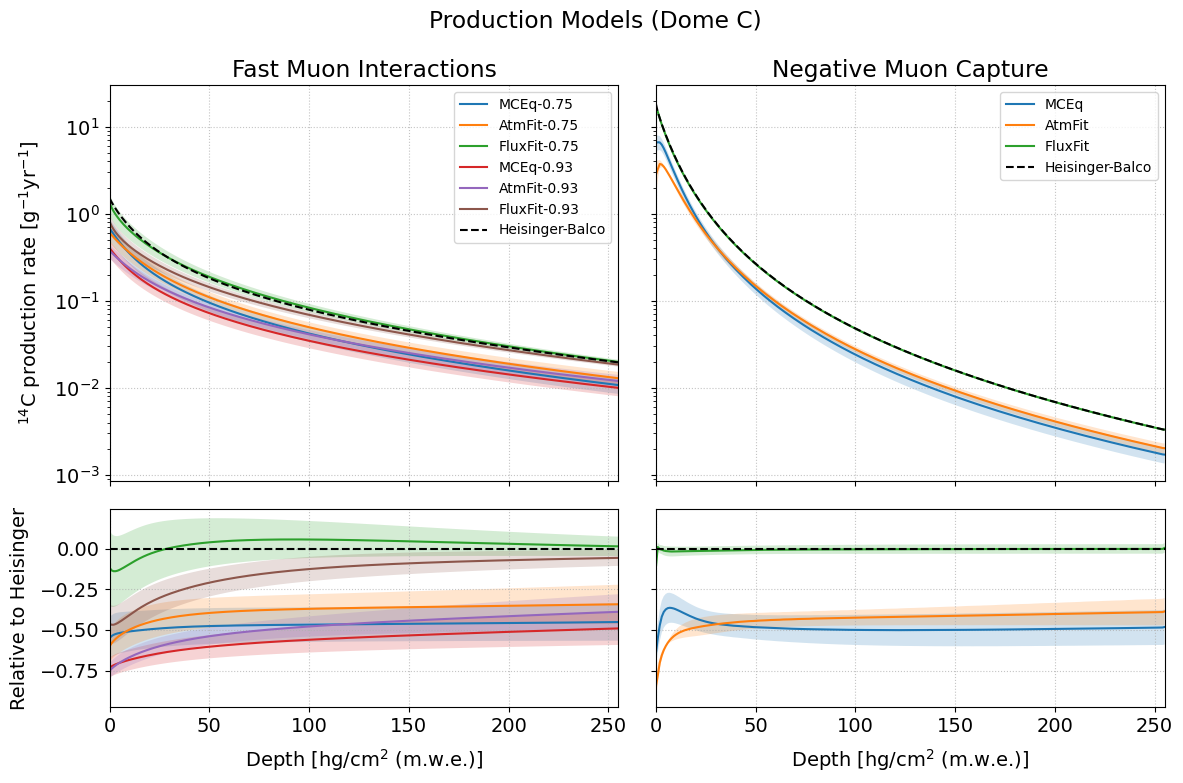

In [50]:
# Plot Production Rates w/ Depth
fig, axes = plt.subplots(2,2, figsize=(12,8), tight_layout=True, sharex = True, sharey='row', height_ratios=[2,1])

Prop = Prop_DC
h = Prop.h

P_plot = P_avg[:,:,:len(h)]
P_plot = P_plot.reshape((3,2,*P_plot.shape[1:])).swapaxes(0,1).reshape(P_plot.shape)
P_plot_std = np.sqrt(P_cov[:,:,:,np.arange(len(h)),np.arange(len(h))])
P_plot_std = P_plot_std.reshape((3,2,*P_plot_std.shape[1:])).swapaxes(0,1).reshape(P_plot_std.shape)

for i in range(2): # fast, neg
    pH = P_Heisinger[-1,i,:len(h)]
    for j in range(2): # true values, relative
        rel = pH if j==1 else 1.
        
        P_cut = P_plot[:,i] if i==0 else P_plot[:3,i]
        P_std = P_plot_std[:,i,i] if i==0 else P_plot_std[:3,i,i]
        labels = ['{}-{:.2f}'.format(m,a) for a in alpha for m in production_models] if i==0 else production_models
        
        for p,dp,l in zip(P_cut, P_std, labels):
            axes[j,i].fill_between(h, (p-dp)/rel-j, (p+dp)/rel-j, alpha=0.2)
            axes[j,i].plot(h, p/rel-j, label=l)
        axes[j,i].plot(h, pH/rel-j, ls='--', c='k', label='Heisinger-Balco')
        #axes[j,i].plot(h, P_Heisinger[0,i,:len(h)]/rel-j, ls='--', c='k', label='Heisinger')
        if j==0:
            axes[j,i].legend(fontsize=10)
axes[0,0].set(
    title='Fast Muon Interactions',
    xlim=(Prop.h[0],Prop.h[-1]),
    ylabel=r'$^{14}$C production rate [g$^{-1}$yr$^{-1}$]',
    yscale='log',
)
axes[0,1].set(
    title='Negative Muon Capture',
)
axes[1,0].set(
    ylabel='Relative to Heisinger',
    xlabel=r'Depth [hg/cm$^2$ (m.w.e.)]',
)
axes[1,1].set(
    xlabel=r'Depth [hg/cm$^2$ (m.w.e.)]',
)
fig.suptitle('Production Models (Dome C)')
plt.show()

## Production Scaling Factors ($\vec{f}$)

In [51]:
sigma_E = 4.5e-28
dsigma_E = 2.5e-28

f_tot = 0.1828 * 0.137 #4.4e-3 #<- fake; where did I get this value?
df_tot = 0.1828 * 0.011 #2.6e-3 #<- nope!

Omega_CO = 0.3

f_fast_H = Omega_CO
df_fast_H = Omega_CO * dsigma_E/sigma_E

f_neg_H = Omega_CO
df_neg_H = Omega_CO * df_tot/f_tot

f_avg = np.array([f_fast_H, f_neg_H])
f_cov = np.diag(np.array([df_fast_H, df_neg_H])**2)
f_cov_inv = np.diag(np.array([df_fast_H, df_neg_H])**-2)
f_std = np.diag([df_fast_H, df_neg_H])

In [52]:
def u_to_f(u):
    return f_avg + f_std @ scipy.stats.norm.ppf(u)

In [53]:
df = 0.01
f_fast_bins = np.arange(0.,1.+df/2,df)
#f_fast_bins = np.array([0.14,0.16])
f_fast = (f_fast_bins[:-1]+f_fast_bins[1:])/2
df_fast = np.diff(f_fast_bins)
f_neg_bins = np.arange(0.,1.+df/2,df)
#f_neg_bins = np.array([0.14,0.16])
f_neg = (f_neg_bins[:-1]+f_neg_bins[1:])/2
df_neg = np.diff(f_neg_bins)

f = np.array(np.meshgrid(f_fast,f_neg, indexing='ij')).reshape((2,-1)).T
df2 = (df_fast.reshape((-1,1))*df_neg.reshape((1,-1))).reshape((-1))
#axis0 - f-factors
#axis1 - Production Mode
f.shape

(10000, 2)

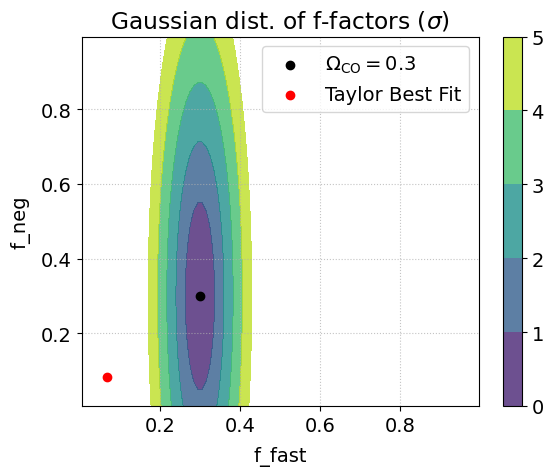

In [54]:
chi2_H = ((f_fast-f_fast_H)/df_fast_H).reshape((-1,1))**2+((f_neg-f_neg_H)/df_neg_H).reshape((1,-1))**2
sig_H = stats.norm.isf(stats.chi2.sf(chi2_H,2)/2)
L_H = np.exp(-chi2_H/2)/np.sqrt((2*np.pi)**2*df_fast_H*df_neg_H)*df_fast.reshape((-1,1))*df_neg.reshape((-1,1))
cont = plt.contourf(f_fast,f_neg, sig_H, alpha=0.8, levels=np.arange(6))
#cont = plt.contourf(f_fast,f_neg, np.log(L_H), alpha=0.8)
plt.colorbar(cont)
plt.scatter(0.3,0.3,c='k', label=r'$\Omega_{\text{CO}} = 0.3$')
plt.scatter(0.067,0.084, c='r', label='Taylor Best Fit')
plt.xlabel('f_fast')
plt.ylabel('f_neg')
plt.legend()
plt.title(r'Gaussian dist. of f-factors ($\sigma$)')
plt.show()

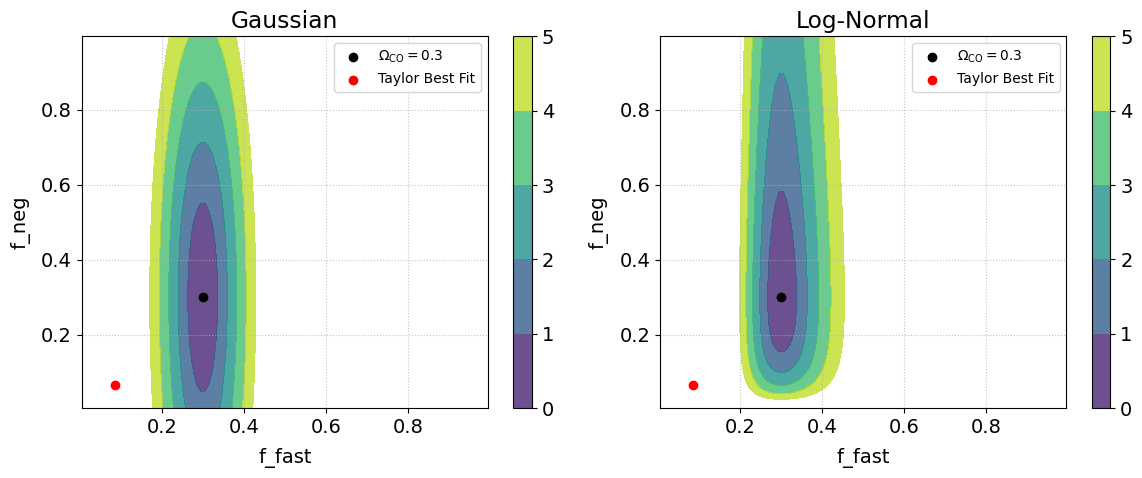

In [55]:
fig, axes = plt.subplots(1,2, figsize=(12,5), tight_layout=True)

f_TG = np.array([0.085, 0.068])

chi2_H = ((f_fast-f_fast_H)/df_fast_H).reshape((-1,1))**2+((f_neg-f_neg_H)/df_neg_H).reshape((1,-1))**2
sig_H = stats.norm.isf(stats.chi2.sf(chi2_H,2)/2)
L_H = np.exp(-chi2_H/2)/np.sqrt((2*np.pi)**2*df_fast_H*df_neg_H)*df_fast.reshape((-1,1))*df_neg.reshape((-1,1))
cont = axes[0].contourf(f_fast,f_neg, sig_H, alpha=0.8, levels=np.arange(6))
#cont = plt.contourf(f_fast,f_neg, np.log(L_H), alpha=0.8)
plt.colorbar(cont)
axes[0].scatter(0.3,0.3,c='k', label=r'$\Omega_{\text{CO}} = 0.3$')
axes[0].scatter(*f_TG, c='r', label='Taylor Best Fit')
axes[0].set(
    xlabel='f_fast',
    ylabel='f_neg',
    title='Gaussian',
)
axes[0].legend(fontsize=10)

chi2_H = ((np.log(f_fast)-np.log(f_fast_H))/np.log(1+df_fast_H/f_fast_H)).reshape((-1,1))**2+((np.log(f_neg)-np.log(f_neg_H))/np.log(1+df_neg_H/f_neg_H)).reshape((1,-1))**2
sig_H = stats.norm.isf(stats.chi2.sf(chi2_H,2)/2)
L_H = np.exp(-chi2_H/2)/np.sqrt((2*np.pi)**2*np.log(1+df_fast_H/f_fast_H)*np.log(1+df_neg_H/f_neg_H))*(df_fast/f_fast).reshape((-1,1))*(df_neg/f_neg).reshape((-1,1))
cont = axes[1].contourf(f_fast,f_neg, sig_H, alpha=0.8, levels=np.arange(6))
#cont = plt.contourf(f_fast,f_neg, np.log(L_H), alpha=0.8)
plt.colorbar(cont)
axes[1].scatter(0.3,0.3,c='k', label=r'$\Omega_{\text{CO}} = 0.3$')
axes[1].scatter(*f_TG, c='r', label='Taylor Best Fit')
axes[1].set(
    xlabel='f_fast',
    ylabel='f_neg',
    title='Log-Normal',
)
axes[1].legend(fontsize=10)
#plt.suptitle(r'Potential f-factor Distributions ($\sigma$) of Heisinger+ Uncertainties')
plt.show()

## CR History ($\vec{\phi}$)

In [56]:
def u_to_phi(u):
    # transform uniformly distributed Unit Cube to prior distribution on phi
    return 2*u

In [57]:
phi0 = np.ones((len(t_CR)))

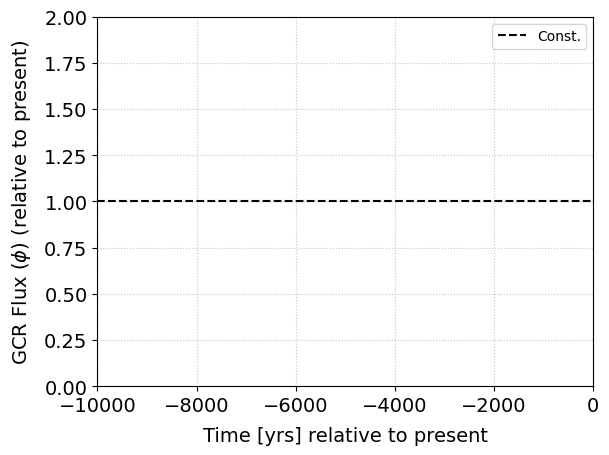

In [58]:
#plt.plot(t, phi.T, c='grey')
#plt.axvspan(t_CR[0], t_bins_DC[0], color='grey', ls='--', alpha=0.2)
#plt.fill_between(t_CR, 1+t_scale.clip(min=-1)*0.5, 1-t_scale.clip(min=-1)*0.5, alpha=0.5, label='Linear 50%')
#plt.fill_between(t_CR, 1-0.5*(t_scale<-0.5), 1+0.5*(t_scale<-0.5), alpha=0.5, label='Step 50%')
plt.plot(t_CR, phi0, c='k', ls='--', label='Const.')
plt.xlim(t_CR[0],t_CR[-1])
plt.ylim(0,2)
plt.xlabel('Time [yrs] relative to present')
plt.ylabel(r'GCR Flux ($\phi$) (relative to present)')
plt.legend(fontsize=10)
#plt.title('GCR Flux Models vs Time')
plt.show()

## Atmospheric $^{14}$CO History ($\vec{C}^{\text{atm}}$)

In [59]:
def C14_unit_convert(C14_in,unit_in,unit_out):#,date,d13C,MixR):
    # Constants
    Navo = 6.022140857E23
    scc_mol = 22414
    Aabs = 1.1764E-12
    tau = 8267
    
    # molec/ccSTP --> ppmE-12
    if (unit_in=='molec' and unit_out=='ppm'):
        return C14_in * scc_mol / Navo * 10**18

    # ppmE-12 -> molec/ccSTP
    if (unit_in=='ppm' and unit_out=='molec'):
        return C14_in / scc_mol * Navo / 10**18

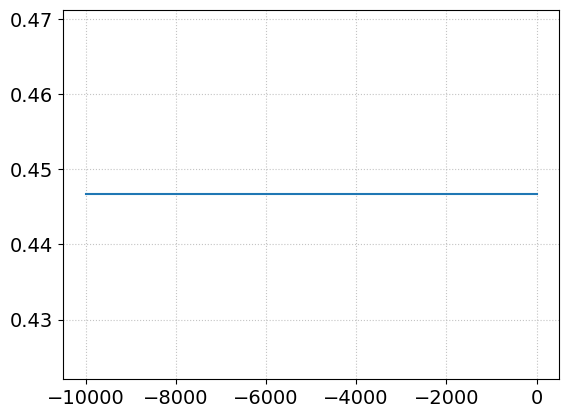

In [60]:
# Atmospheric 14CO history
C14CO_const = 12 # constant 14CO history (molec/ccSTP)

gas_history = C14_unit_convert(C14CO_const, 'molec', 'ppm') * np.ones(len(t_atm))
plt.plot(t_atm, gas_history)

## Reservoir Partition ($\vec{R}$) and Leakage Rates ($\vec{L}$)

In [61]:
L = np.array([1, 7e-4]) # Ice Grain Leakage Rates (yr^-1)
L

array([1.e+00, 7.e-04])

In [62]:
Res = np.array([1-1e-2, 1e-2])
Res /= np.sum(Res)
Res

array([0.99, 0.01])

# Accumulation Tensor ($\vec{A}$)

## Taylor Glacier (Solid Ice)

$$\hat{A}_{f,p,t} = \hat{\delta}_{f+t_A,p}\cdot e^{\lambda t_A}dt_A \hat{\delta}_{t_A,t}$$

In [63]:
flow='best'
#flow = 'trim'
if flow=='best' or flow=='sample':
    flowpath = loadmat('matlab/MC_14CO_mod/flowpath_sample.mat')
    h_age = flowpath['h_age']
elif flow=='all':
    flowpath = loadmat('matlab/MC_14CO_mod/flowpath_all.mat')
    h_age = flowpath['h_age']
else:
    flowpath = loadmat('matlab/MC_14CO_mod/flowpath_trim.mat')
    h_age = np.swapaxes(flowpath['h_trim'], 1,2)
# h_age : ice parcel depth as a function of age [m]
#axis0 - sample depth
#axis1 - flowpath
#axis2 - ice parcel age

age = flowpath['age'][0]
# age : ice parcel ages [years]
#axis0 - ice parcel age
h_age.shape

(8, 1, 861)

In [64]:
t_A_TG_bins = np.arange(int(10000/dt_A)+1)*dt_A
t_A_TG_bins = t_A_TG_bins - t_A_TG_bins[-1]
t_A_TG = get_bins(t_A_TG_bins)[0]

t_A_TG.shape

(20000,)

In [65]:
h_prop_TG = np.arange(1001)

In [66]:
delta_tAt = interp_mat(t_A_TG[:,None], t_CR[None,:])

In [67]:
delta_tAage = interp_mat(t_A_TG[:,None], -age[None,::-1], left=True)

In [68]:
delta_stAp = interp_mat((-h_age[:,:,::-1] @ delta_tAage.T)[:,:,:,None], Prop_TG.h[None,None,None,:])

In [69]:
A_TG = np.einsum('siAp, At -> sipt', delta_stAp, delta_tAt, optimize=True)
A_TG.shape
#axis0 - sample depth (s)
#axis1 - flowpath (i)
#axis2 - production depth (p)
#axis3 - CR time (t)

(8, 1, 1001, 501)

## Dome C, above close-off (Firn)

### Setup Firn Site Functions

#### Porosity ($s(z)$)

Define the ice density profile of Dome C and the open, closed, total porosity $s$ with depth.

$$\rho(z) = dh(z)/dz$$

$$s(z) = 1-\rho(z)/\rho_{ice}$$

$$s_c(z) = 0.37s(z) * (\frac{s(z)}{1-\rho_{co}/\rho_{ice}})^{-7.6}$$

$$s_o(z) = s(z) - s_c(z)$$

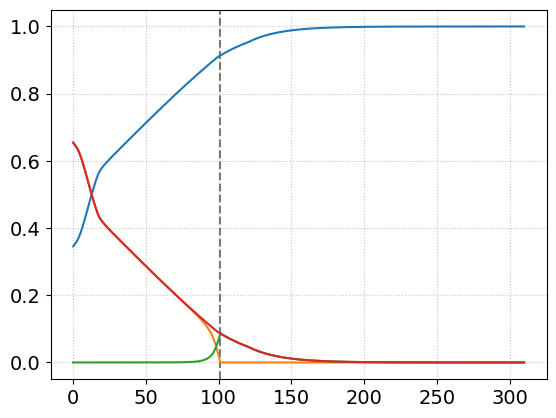

In [70]:
plt.axvline(DC.z_grid[DC.teller_co], ls='--', c='k', alpha=0.5)
plt.plot(DC.z_grid, DC.rho/DC.rho_ice)
plt.plot(DC.z_grid, DC.s_open)
plt.plot(DC.z_grid, DC.s_closed)
plt.plot(DC.z_grid, DC.s)

#### Bubble Pressure ($b_p(z)$) & Velocity ($v(z)$)

$$v_{ice}(z) = dz/dage = Acc/\rho$$

In the firn, we calculate the bubble pressure by the integral:

$$b_p(z) = \frac{\int_0^z \frac{ds_c(z')}{dz'}e^{M_{air}g z'/RT} s(z')/ (1+\int_{z'}^z \frac{d\ln v_{ice}(z'')}{dz''} dz'')dz'}{s(z)\int_0^z \frac{ds_c(z')}{dz'} dz'} $$

I can't help but notice we're taking the integral of derivatives here.  Makes it pretty easy to simplify,

$$b_p(z) = \frac{\int_0^z \frac{ds_c(z')}{dz'}e^{M_{air}g z'/RT} s(z') /(1+\ln v_{ice}(z) - \ln v_{ice}(z'))dz'}{s(z)[s_c(z)-s_c(0)]}$$

We also calculate the flux of air through the close-off depth:

$$flux = b_p(z_{co+1}) s_c(z_{co+1}) v_{ice}(z_{co+1})$$

The velocity:

$$v(z) = \begin{cases}\displaystyle
\frac{flux - v_{ice} * b_p * s_c}{C * s_o} & <v_{ice}(z)\\
v_{ice}(z) & \text{else}
\end{cases}$$

And the air content:

$$a_c = 1000 * \frac{b_p(z_{co+1}) * s_c(z_{co+1})}{\rho(z_{co+1})} * \frac{pressure}{101325} * \frac{273.15}{T}$$

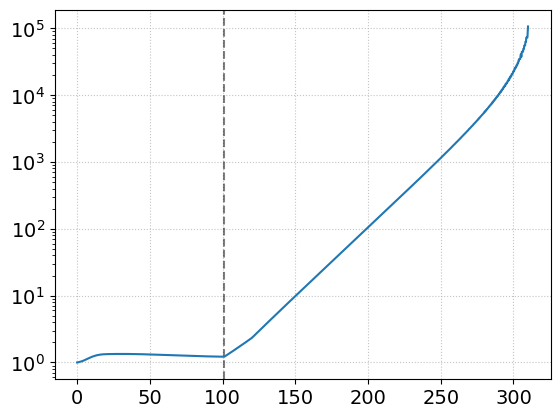

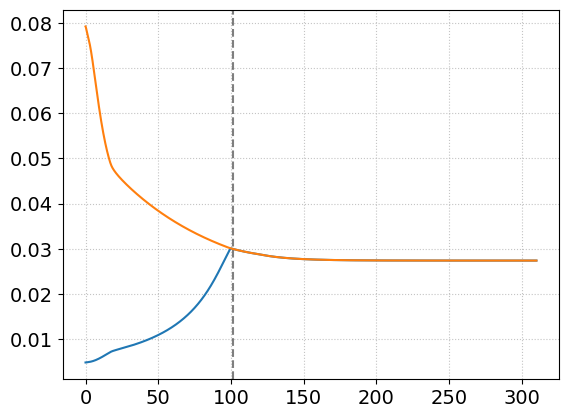

In [71]:
plt.axvline(DC.z_grid[DC.teller_co], ls='--', c='k', alpha=0.5)
plt.plot(DC.z_grid, DC.bubble_pres)
plt.yscale('log')
plt.show()

plt.axvline(DC.z_grid[DC.teller_co], ls='--', c='k', alpha=0.5)
plt.plot(DC.z_grid, DC.velocity)#*(60*60*24*365.25))
#plt.plot(z, (flux + 1e-10 - v_ice * bubble_pres * s_closed) / ((s_open + 1e-10) * C_air))
plt.plot(DC.z_grid, DC.v_ice)
#plt.plot(z, Dome_C.v_ice)
plt.show()

#### Trapping Rate ($\text{tr}(z)$)

The trapping rate of open porosity gas into closed porosity gas is given by the change in the number density of closed porsosity gas particles per unit time:

$$trapping(z) = \rho(z)\frac{d(s_c*b_p)}{dz}$$

Since all of these new gas particles entering the closed porosity of our ice parcel come from the open porosity, the additional $^{14}$CO concentration ($c(z)$) they bring is the integral over time of the open porosity concentration ($c_o(z,t)$) times the trapping rate ($tr(z)$) times the fraction of $^{14}$C which has since decayed ($e^{-\lambda (t-t')}$), divided by the total gas in closed porosity ($\int_{t_0}^t tr(z(t'))\,dt'$).

$$c(z,t) = \frac{\int_{t_0}^{t} c_o(z(t'),t')\,tr(z(t'))\,e^{-\lambda (t-t')}\,dt'}{\int_{t_0}^t tr(z(t'))\,dt'}$$

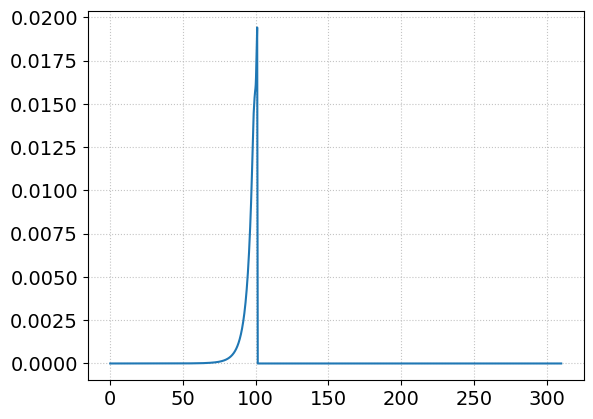

In [72]:
plt.plot(DC.z_grid, DC.trapping_t)

#### Diffusion Matrix ($\hat{D}^{dt}_{dd'}$)

##### Crank-Nicholson Parameters ($\alpha$, $\beta$, $\gamma$)

The differential equation describing the diffusion of our open porosity gas concentration $c$ is:

$$\frac{\partial c}{\partial t} = \alpha\frac{\partial^2 c}{\partial z^2} + \beta\frac{\partial c}{\partial z} + \gamma c$$

where

$$\alpha = D + D_e$$

$$\beta = \frac{[D*(M_{air}-M_{^{14}CO}) + D_e*M_{air}]*g}{R*T} + \frac{d((D+D_e)*C_{air}*s_o)}{s_o*C_{air}\,dz} - v$$

$$\gamma = \frac{d(D*C_{air}*s_o)}{s_o*C_{air}\,dz}\frac{(M_{air}-M_{^{14}CO})*g}{R*T} - \lambda$$

$D = InvTort * D_{trace}$ - Diffusivity

$D_e$ - Eddie diffusivity

$C_{air} = e^{M_{air}gz/RT}$ - "Barometric equation", open porosity pressure relative to surface, I think?

$M_{air}$ - molar mass of air

$M_{trace}$ - molar mass of $^{14}$CO

$L_{trace}$ - decay rate of $^{14}$CO

The function below calculates $\alpha' = \alpha \frac{dt}{2dz^2}$, $\beta' = \beta \frac{dt}{4dz}$, and $\gamma' = \gamma \frac{dt}{2}$, for reasons that will be explained in the following section.

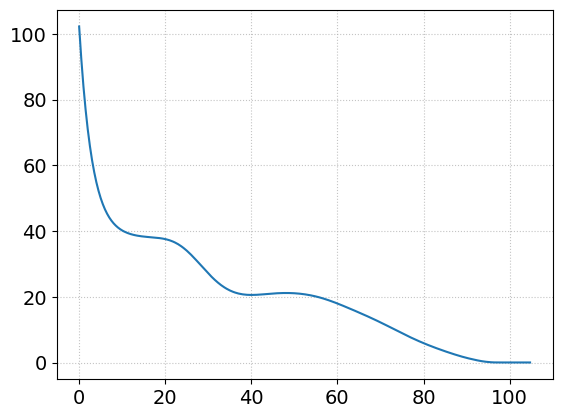

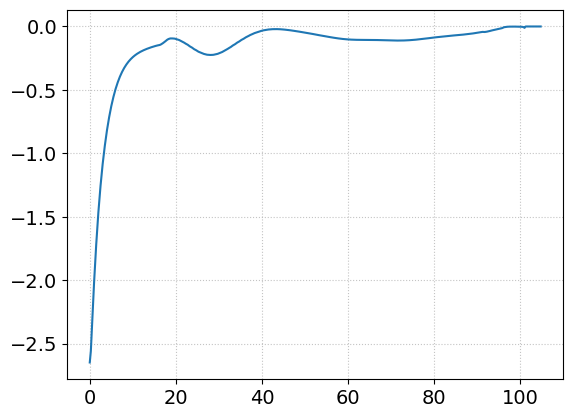

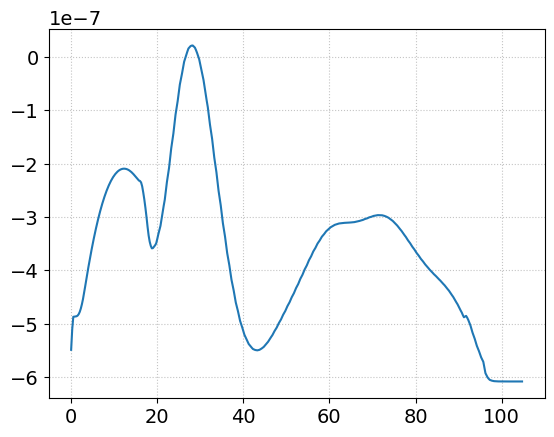

In [73]:
plt.plot(DC.z_D[:DC.Q], DC.alpha[:DC.Q])
plt.show()

plt.plot(DC.z_D[:DC.Q], DC.beta[:DC.Q])
plt.show()

plt.plot(DC.z_D[:DC.Q], DC.gamma[:DC.Q])
plt.show()

##### Crank-Nicholson Matrices

To solve the diffusion PDE:

$$\frac{\partial}{\partial t}c = \alpha\frac{\partial^2}{\partial z^2}c + \beta\frac{\partial}{\partial z}c + \gamma c$$

We approximate our spatial derivates as the average between timesteps $t+1$ and $t$:

$$\frac{c^{t+1}-c^t}{\Delta t} = \frac{\alpha}{2(\Delta z)^2}((c^{t+1}_{i+1}-2c^{t+1}_i+c^{t+1}_{i-1})+(c^t_{i+1}-2c^t_i+c^t_{i-1})) + \frac{\beta}{4\Delta z}((c^{t+1}_{i+1}-c^{t+1}_{i-1})+(c^t_{i+1}-c^t_{i-1})) + \frac{\gamma}{2}(c^{t+1}_i + c^{t}_i)$$

Moving our timesteps $t+1$ and $t$ to opposite sides of the equation,

$$-(\alpha' + \beta')c^{t+1}_{i+1} + (1 + 2\alpha' - \gamma')c^{t+1}_i - (\alpha' - \beta')c^{t+1}_{i-1} = (\alpha' + \beta')c^{t}_{i+1} + (1 - 2\alpha' + \gamma')c^{t}_i + (\alpha' - \beta')c^{t}_{i-1}$$

We can rewrite this as a matrix product on $c^{t+1}$ and $c^t$:

$$A_{i,i-1} = \alpha'_i - \beta'_i; \quad A_{i,i} = -2\alpha'_i + \gamma'_i; \quad A_{i,i+1} = \alpha'_i + \beta'_i$$

$$(I-A)c^{t+1} = (I+A)c^t$$

Which we can solve by inversion:

$$c^{t+1} = (I-A)^{-1}(I+A)c^t$$

The ice starts uniformly filled with the same $^{14}$CO concentration as the atmosphere.

After each timestep, the concentration at the top of the ice is set to the current atmospheric $^{14}$CO concentration.

Cosmogenic $^{14}$CO is also being injected into our gas, so after each timestep we add the extra $^{14}$CO leaking out of the grains.

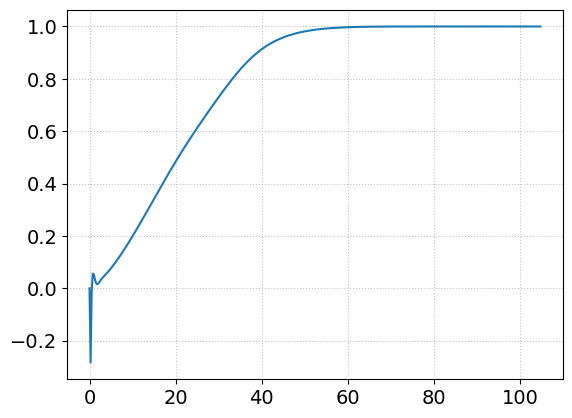

In [74]:
D_A = np.linalg.matrix_power(DC.D,int(DC.dt_A/DC.dt_D))
plt.plot(DC.z_D[:DC.Q], np.sum(D_A, axis=1))

#### Unit Conversions ($U(z)$)

$$U_{g\rightarrow ppm}(z) = \frac{RT * 10^{18}}{N_A P \frac{s_o(z)}{\rho(z)} e^{M_{air} g z/(RT)} * 10^{-6}}$$

$$U_{ppm\rightarrow g}(z) = \frac{N_A P \frac{s_c(z)}{\rho(z)} b_p(z) * 10^{-6}}{RT * 10^{18}}$$

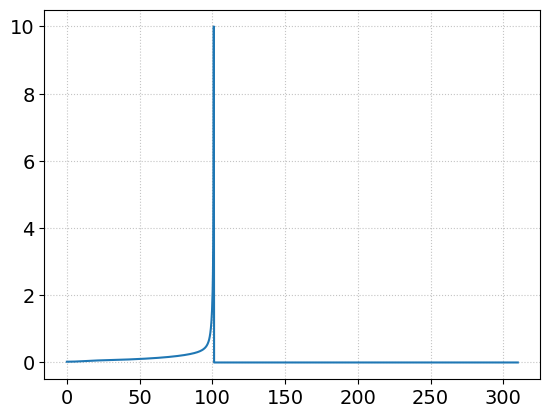

In [75]:
plt.plot(DC.z_grid, DC.gram_to_ppm)

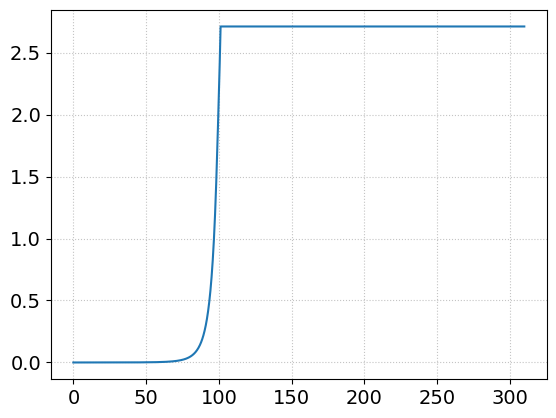

In [76]:
plt.plot(DC.z_grid, DC.ppm_to_gram_cl)

### Ice Grains (In Situ)

$$\vec{c}^{\text{grains}}_f = \sum_{p,t,r}\hat{A}^{\text{grains}}_{f,p,t,r}\vec{P}_p\vec{\phi}_{t} \vec{R}_r$$

$\vec{c}^{\text{grains}}_f$ - Prediced ice grain $^{14}$CO concentration [molecules g$^{-1}$] at final depth $f$

$\vec{P}_p$ - Production Rates [molecules g$^{-1}$ yr$^{-1}$], Total present-day in situ $^{14}$CO production rate at production depth $p$

$\vec{\phi}_t$ - CR History [unitless], flux of cosmic ray muons at production time $t$, relative to present ($t=0$)

$\vec{R}_r$ - Reservoir Partition [unitless], fraction of in situ $^{14}$CO partitioned into ice grain reservoir $r$

$$\hat{A}^{\text{grains}}_{f,p,t,r} = \vec{\Lambda}_r^{-t_A}dt_A\, \hat{\delta}_{f,a-t_A} \cdot \hat{\delta}_{a,p}\cdot \hat{\delta}_{t_A,t}$$

$\hat{A}^{\text{grains}}_{f,p,t,r}$ - Ice Grain Accumulation Tensor [yrs], Contribution to present-day $^{14}$CO concentration in ice grains at final depth $f$ from production depth $p$, production time $t$, and reservoir $r$

$\hat{\delta}_{t_A,t}$ - Interpolation matrix [unitless] from production time $t$ to accumulation time $t_A$, s.t. $t_A \approx t$

$\hat{\delta}_{a,p}$ - Interpolation matrix [unitless] from production depth $p$ to accumulation depth $a$, s.t. $h_a \approx h_p$

$\hat{\delta}_{f,a-t_A}$ - Interpolation matrix [unitless] from accumulation depth $a-t_A$ to final depth $f$, s.t. $z_f \approx z_{a-t_A} = z(\text{age}(z_a)-t_A)$

$\vec{\Lambda}_r = (1-\vec{L}_r) e^{-\lambda}$ - Ice grain loss rate [unitless], fraction of $^{14}$CO in reservoir $r$ lost to decay & leakage in one year

$\vec{L}_r$ - Annual leakage rate [unitless] of reservoir $r$

In [77]:
const = False # simplify calculation to assume constant CR flux
z_end = 120 # depth [m] where we switch from firn model to solid ice model

In [ ]:
COS_partition = np.array(
    [#CO2         CO          CH4
    [0.686307104, 0.31125305, 0.002439846], # neutron
    [0.686307104, 0.31125305, 0.002439846], # neg muon
    [0.686307104, 0.31125305, 0.002439846], # fast muon
])

In [78]:
COS_P = np.array(DC.COS_Production(Prop_DC.h)).T
f = np.array([COS_partition[0,1], 0.04, 0.06])
P = COS_P @ f
phi = phi0

In [79]:
grains, leak_open, cumuleak_closed = DC.Calc_14C_ice(h_p=Prop_DC.h, P=P)
C14_open, C14_closed, C14_open_atm, C14_closed_atm, c_gases = DC.Calc_profiles(leak_open, gas_history)

/mnt/c/users/walte/Documents/python-scripts/In-Situ-14C/InSitu14CO.py:591: RuntimeWarning: divide by zero encountered in log
  Lrate = -np.log(1-L)
/mnt/c/users/walte/Documents/python-scripts/In-Situ-14C/InSitu14CO.py:593: RuntimeWarning: invalid value encountered in multiply
  Ctemp = np.exp(-(Site.lambd+Lrate)[None,None,:]*(Site.age_A+Site.dt_A)[:,None,None]) * np.cumsum(P_A[:,:,None] * np.exp((Site.lambd+Lrate)[None,None,:]*Site.age_A[:,None,None]) * Site.dt_A, axis=0)


0.02376413345336914
interpolating...


100%|█████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00,  8.25it/s]


integrating...
  Calculated open and closed profiles for gas
1.3317592144012451


In [80]:
delta_fA = interp_mat(z_f_DC[:,None],np.array([0,*DC.z_A])[None,:])[:,1:]
delta_Ap = interp_mat(DC.h_A[:,None],Prop_DC.h[None,:])

A_end = np.arange(len(DC.z_A))[DC.z_A>z_end][0]

f_end = np.arange(len(z_f_DC))[z_f_DC<DC.z_A[A_end-1]][-1]+1
p_end = np.arange(len(Prop_DC.z))[Prop_DC.z>DC.z_A[A_end-1]][0]+1
t_start = np.arange(len(t_CR))[t_CR<-DC.age_A[A_end-1]][-1]

z_f_end = np.array([*z_f_DC[:f_end],DC.z_A[A_end-1]])
delta_fAend = np.concatenate((delta_fA[:f_end,:A_end], np.zeros((1,A_end))), axis=0)
delta_fAend[-1,-1] = 1

t = -np.arange(A_end)-1 # integration timesteps, from formation of first ice (in range) to present, centered on left side of bin
if True:
    A_grains_const = np.zeros((f_end+1, A_end, len(L)))
    for i in tqdm(t): # step through integration time (i)
        # scale new 14CO by leak&decay fraction, then interpolate from accumulation depth + remaining time to final depth grid
        A_grains_const[:,:i,:] += delta_fAend[:,-i:,None] * (1-L[None,None,:])**(-i*DC.dt_A)* np.exp(DC.lambd*i*DC.dt_A) * DC.dt_A
    # interpolate from production depths to accumulation depths
    A_grains_const = delta_Ap[:A_end,:p_end].T @ A_grains_const
    A_grains_const.shape

100%|██████████████████████████████████████████████████████████████████████████████| 6388/6388 [00:28<00:00, 223.83it/s]


In [81]:
if not const:
    A_grains = np.zeros((f_end+1, A_end, len(t_CR[t_start:]), len(L)))

    t_ratio = int(dt_CR/DC.dt_A)

    t = -np.arange(A_end)-1
    # for efficiency, we manually perform the dot product with delta_At
    for i in tqdm(t): # integration timesteps, from formation of first ice (in range) to present, centered on left side of bin
        j = i//t_ratio # bin index of current time in CR timescale resolution
        k = (i%t_ratio+0.5)/t_ratio # integration time bin center's fraction of the way between CR time grid points
        # scale new 14CO by leak&decay fraction, then interpolate from accumulation depth + remaining time to final depth grid
        x = delta_fAend[:,-i:,None] * (1-L[None,None,:])**(-i*DC.dt_A)* np.exp(DC.lambd*i*DC.dt_A) * DC.dt_A
        A_grains[:,:i,j,:] += x * (1-k) # interpolation contribution from CR time j
        A_grains[:,:i,j+1,:] += x * k # interpolation contribution from CR time j+1
    A_grains = np.einsum('fAtl, Ap -> fptl', A_grains, delta_Ap[:A_end,:p_end], optimize=True)
    A_grains.shape

100%|███████████████████████████████████████████████████████████████████████████████| 6388/6388 [02:41<00:00, 39.64it/s]


/tmp/ipykernel_3523/582852643.py:5: RuntimeWarning: invalid value encountered in divide
  axes[1].plot(DC.z_grid, (grains[:,0]@Res / (grains[:,0]@Res) -1)*100, label='Firn Model')
/tmp/ipykernel_3523/582852643.py:8: RuntimeWarning: invalid value encountered in divide
  axes[1].plot(z_f_end, (np.einsum('fpl, p, l -> f', A_grains_const, P[:p_end], Res, optimize=True)/rel - 1)*100, label='Tensor const')
/tmp/ipykernel_3523/582852643.py:11: RuntimeWarning: invalid value encountered in divide
  axes[1].plot(z_f_end, (np.einsum('fptr, p, t, r -> f', A_grains, P[:p_end], phi[t_start:], Res, optimize=True)/rel - 1)*100, label='Tensor var')


[Text(0, 0.5, 'Residual (%)'), Text(0.5, 0, 'Depth [m]')]

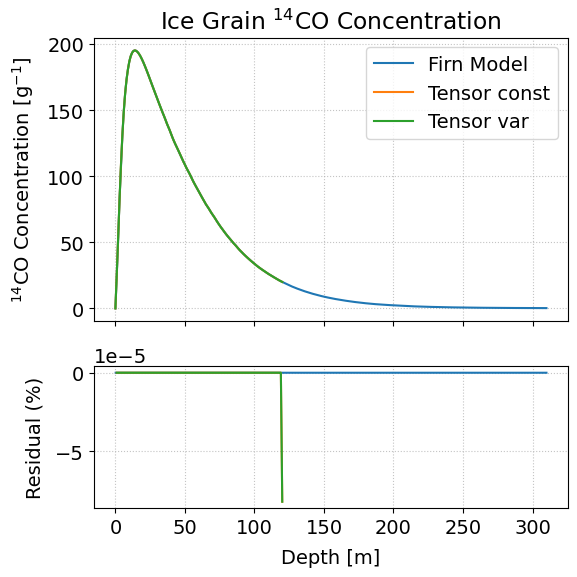

In [82]:
fig, axes = plt.subplots(2,1, figsize=(6,6), tight_layout=True, sharex = True, sharey=False, height_ratios=[2,1])

rel = np.interp(z_f_end, DC.z_grid, grains[:,0]@Res)
axes[0].plot(DC.z_grid, grains[:,0]@Res, label='Firn Model')
axes[1].plot(DC.z_grid, (grains[:,0]@Res / (grains[:,0]@Res) -1)*100, label='Firn Model')
if True:
    axes[0].plot(z_f_end, np.einsum('fpl, p, l -> f', A_grains_const, P[:p_end], Res, optimize=True), label='Tensor const')
    axes[1].plot(z_f_end, (np.einsum('fpl, p, l -> f', A_grains_const, P[:p_end], Res, optimize=True)/rel - 1)*100, label='Tensor const')
if not const:
    axes[0].plot(z_f_end, np.einsum('fptr, p, t, r -> f', A_grains, P[:p_end], phi[t_start:], Res, optimize=True), label='Tensor var')
    axes[1].plot(z_f_end, (np.einsum('fptr, p, t, r -> f', A_grains, P[:p_end], phi[t_start:], Res, optimize=True)/rel - 1)*100, label='Tensor var')


    
axes[0].legend()
axes[0].set(
    ylabel=r'$^{14}$CO Concentration [g$^{-1}$]',
    title=r'Ice Grain $^{14}$CO Concentration',
)

axes[1].set(
    ylabel='Residual (%)',
    xlabel='Depth [m]',
)

### Open Porosity (from Atm)

$$\vec{c}^{\text{open}}_{f} = \sum_{p,t,r} \hat{A}^{\text{open}}_{f,p,t,r}\vec{P}_{p}\vec{\phi}_{t}\vec{R}_r + \sum_{t}\hat{A}^{\text{atm}}_{f,t}\vec{C}^{\text{atm}}_{t_{atm}}$$

$\vec{c}^{\text{open}}_{f}$ - Predicted open porosity $^{14}$CO concentration [ppm] at final depth $f$

$\vec{C}^{\text{atm}}_{t_{atm}}$ - Atmospheric $^{14}$CO History [ppm], Concentration of $^{14}$CO in the atmosphere at time $t_{atm}$

$$\hat{A}^{\text{atm}}_{f,t_{atm}} = \hat{\delta}_{f,d}\cdot [\sum_{t_D=0}^{dt_A} D^{t_D}_{d,d'}]\cdot D^{-t_A}_{d',0} \cdot \hat{\delta}_{t_A,t_{atm}}$$

$\hat{A}^{\text{atm}}_{f,t_{atm}}$ - Open Porosity Atmospheric Accumulation Tensor [unitless], Contribution to present-day $^{14}$CO concentration in open porosity at final depth $f$ from atmospheric $^{14}$CO at time $t_{atm}$

$D^{t}_{d,d'}$ - Diffusion matrix [unitless], transforms open porosity $^{14}$CO concentration at initial diffusion depth $d'$ to new diffusion depth $d$ after duration $t$ of diffusion

$\hat{\delta}_{t_A,t_{atm}}$ - Interpolation matrix [unitless] from atmospheric time $t_{atm}$ to accumulation time $t_A$, s.t. $t_A \approx t_{atm}$

$\hat{\delta}_{f,d}$ - Interpolation matrix [unitless] from diffusion depth $d$ to final depth $f$, s.t. $z_f \approx z_d$

100%|██████████████████████████████████████████████████████████████████████████████| 1999/1999 [00:02<00:00, 941.85it/s]


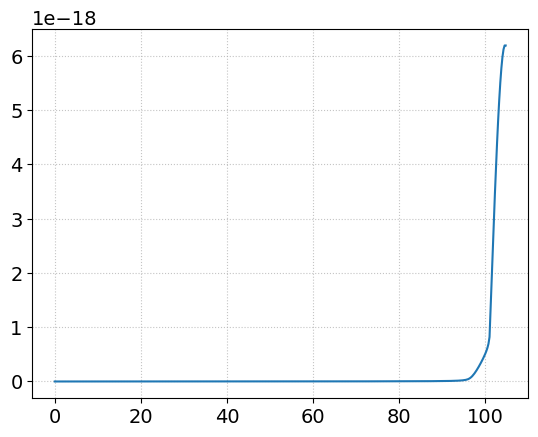

In [83]:
t_D_max = 1000 # max diffusion time (yrs) # At Dome_C, ~1e-12 14CO remains in open firn after 1000 yrs

N_D = int(t_D_max/DC.dt_A) # maximum number of diffusion timesteps worth considering
D_t = np.moveaxis(cum_mat_prod(D_A,N_D),0,-1)

# after 1000 years only ~1e-12 of 14CO is left
plt.plot(DC.z_D[:DC.Q], np.sum(D_t[:,:,-1],axis=-1))

In [84]:
if DC.z_D[0]>0:
    delta_fd = interp_mat(z_f_DC[:,None],np.array([0,*DC.z_D])[None,:])[:,1:]
else:
    delta_fd = interp_mat(z_f_DC[:,None],DC.z_D[None,:])
delta_fd[z_f_DC<DC.z_D[0],0]=1
delta_fd[z_f_DC<DC.z_D[0],1:]=0

delta_Atatm = interp_mat(DC.t_A[:,None],t_atm[None,:])
atm_start = -int(N_D*DC.dt_A/dt_atm)

#A_open_atm = delta_fd[:f_end,:DC.Q] @ (np.sum(cum_mat_prod(DC.D,int(DC.dt_A/DC.dt_D)), axis=0)[:,0] @ D_t[:,:,::-1]) @ delta_Atatm[-N_D:,atm_start:]
A_open_atm = (np.sum(cum_mat_prod(DC.D,int(DC.dt_A/DC.dt_D)), axis=0)[:,0] @ D_t[:,:,::-1]) @ delta_Atatm[-N_D:,atm_start:]
#axis0 - final depth (f)
#axis1 - atmospheric time (t_atm)
A_open_atm.shape

100%|█████████████████████████████████████████████████████████████████████████████████| 49/49 [00:00<00:00, 1426.73it/s]


(420, 100)

[Text(0, 0.5, 'Residual (%)'), Text(0.5, 0, 'Depth [m]')]

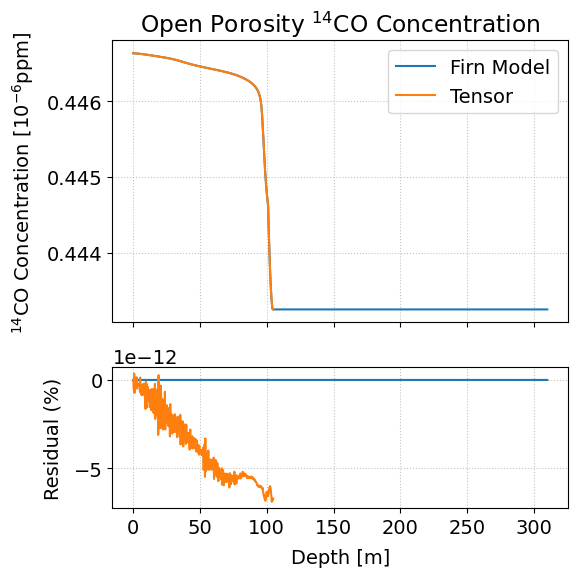

In [85]:
fig, axes = plt.subplots(2,1, figsize=(6,6), tight_layout=True, sharex = True, sharey=False, height_ratios=[2,1])

rel = c_gases[:,0]
axes[0].plot(DC.z_D, c_gases[:,0], label='Firn Model')
axes[1].plot(DC.z_D, (c_gases[:,0]/c_gases[:,0] - 1)*100, label='Firn Model')

axes[0].plot(DC.z_D[:DC.Q], A_open_atm @ gas_history[atm_start:], label='Tensor')
axes[1].plot(DC.z_D[:DC.Q], ((A_open_atm @ gas_history[atm_start:])/rel[:DC.Q]-1)*100, label='Tensor')

axes[0].legend()

axes[0].set(
    ylabel=r'$^{14}$CO Concentration [$10^{-6}$ppm]',
    title=r'Open Porosity $^{14}$CO Concentration',
)

axes[1].set(
    ylabel='Residual (%)',
    xlabel='Depth [m]',
)

### Open Porosity (from Grains)

$$\hat{A}^{\text{open}}_{f,p,t,r} = [\sum_{t'=0}^{\text{age}_{co}} \hat{\mathcal{D}}_{f,a+t',-t_A-t'} \vec{\Lambda}_r^{t'}(1-\vec{l}_r^{dt'})]dt_A\cdot \hat{\delta}_{a,p} \cdot \hat{\delta}_{t_A,t}$$

$\hat{A}^{\text{open}}_{f,p,t,r}$ - Open Porosity In Situ Accumulation Tensor [yrs], Contribution to present-day $^{14}$CO concentration in open porosity at final depth $f$ from in situ $^{14}$CO at production depth $p$ and production time $t$ in reservoir $r$

$t'$ - Leak time; time spent in grain before leaking into open pores, from production ($t_A$) to leakage ($t_A+t'$), can't be longer than age at close-off depth

$a+t'$ - Leak depth; depth at which $^{14}$CO produced at depth $a$ leaks into open pores, $z^{acc}_{a+t'}=z(age(z^{acc}_a)+t')$

$-t_A-t'$ - Diffusion time; time spent diffusing in open porosity between leakage ($t_A+t'$) and measurement (0)

$\vec{\Lambda}_r = (1-\vec{L}_r) e^{-\lambda}$ - Ice grain loss rate [unitless], fraction of $^{14}$CO in reservoir $r$ lost to decay & leakage in one year

$\vec{l}_r = 1-\vec{L}_r$ - Fraction [unitless] of $^{14}$CO in ice grain reservoir $r$ that hasn't leaked after 1 year.  ($(1-\vec{l}_r^{dt'})$ is the fraction that HAS leaked after time $dt'$)

$\vec{L}_r$ - Annual leakage rate [unitless] of reservoir $r$

$\hat{\delta}_{t_A,t}$ - Interpolation matrix [unitless] from production time $t$ to accumulation time $t_A$, s.t. $t_A \approx t$

$\hat{\delta}_{a,p}$ - Interpolation matrix [unitless] from production depth $p$ to accumulation depth $a$, s.t. $h_a \approx h_p$

$$\hat{\mathcal{D}}_{f,a,t_A} = \hat{\delta}_{f,d}\cdot ([\sum_{t_D=0}^{dt_A} D^{t_D} \frac{dt_D}{dt_A}]\cdot D^{t_A})_{d,d'} U_{g\rightarrow ppm}(z_{d'})\frac{s_o(z_{d'})}{s(z_{d'})} \cdot \hat{\delta}_{d',a}$$

$\hat{\mathcal{D}}_{f,a,t_A}$ - $^{14}$CO Diffusion matrix from accumulation depth $a$ to final depth $f$ with a duration from $t_A$ to $t_A+dt_A$, subdivided into time steps of $t_D$, including a conversion from g to ppm and scaling by the open fraction of porosity.

$s_o(z)$ - Open porosity [unitless] at depth $z$

$s(z)$ - Total porosity [unitless] at depth $z$

$U_{g\rightarrow ppm}(z)$ - Unit conversion [g ppm] from molecules per gram to ppm at depth $z$

$\hat{\delta}_{f,d}$ - Interpolation matrix [unitless] from diffusion depth $d$ to final depth $f$, s.t. $z_f \approx z_d$

$\hat{\delta}_{d',a}$ - Interpolatino matrix [unitless] from accumulation depth $a$ to diffusion depth $d$, s.t. $z_d \approx z_a$

In [86]:
if True:
    delta_da = interp_mat(DC.z_D[:,None], np.array([0,*DC.z_A])[None,:])[:,1:]
    # sum over t', with funky indexing to account for -t'-t''=diffusion time and p+At''=leak depth
    A_open_const = np.zeros((DC.Q, A_end, len(L)))

    U_d = np.interp(DC.z_D[:DC.Q], DC.z_grid, DC.gram_to_ppm * DC.s_open / DC.s.clip(min=1e-20))
    #DU_const = delta_fd[:f_end,:DC.Q] @ np.linalg.inv(np.identity(DC.Q)-DC.D) * U_d[None,:] @ delta_da[:DC.Q,:A_end]
    DU_const = np.linalg.inv(np.identity(DC.Q)-DC.D) * U_d[None,:] @ delta_da[:DC.Q,:A_end]

    dt1 = DC.dt_A
    for t1 in tqdm(range(A_end)): #t1 = time spent in grains before leaking
        A_open_const[:,:A_end-t1,:] += DU_const[:,t1:,None] * (np.exp(-DC.lambd*t1*dt1) * (1-L)**(t1*dt1))[None,None,:]
    A_open_const *= (1-(1-L)**dt1)[None,None,:] * DC.dt_D
    A_open_const = delta_Ap[:A_end,:p_end].T @ A_open_const
    A_open_const.shape

100%|███████████████████████████████████████████████████████████████████████████████| 6388/6388 [01:51<00:00, 57.20it/s]


In [102]:
if not const:
    delta_da = interp_mat(DC.z_D[:,None], np.array([0,*DC.z_A])[None,:])[:,1:]

    D_sum = np.sum(cum_mat_prod(DC.D,int(DC.dt_A/DC.dt_D)) * DC.dt_D/DC.dt_A, axis=0)

    U_d = np.interp(DC.z_D[:DC.Q], DC.z_grid, DC.gram_to_ppm * DC.s_open / DC.s.clip(min=1e-20))

    #A_add = np.zeros((f_end, A_end, N_D+t_ratio))
    t_ratio = int(dt_CR/DC.dt_A)
    t_scale = (np.arange(t_ratio)+0.5)/t_ratio
    t_scale = np.array([t_scale,1-t_scale]).T

    # sum over t', with funky indexing to account for -t'-t''=diffusion time and p+At''=leak depth
    t_end = len(t_CR[t_start:])+(D_t.shape[-1]//t_ratio)+2
    A_open = np.zeros((DC.Q, A_end, t_end, len(L)))#,int(age[Q]/dt1)+N_D))
    #axis0 - final depth (f)
    #axis1 - accumulation depth (a)
    #axis2 - production time (t_P)
    #axis3 - reservoir (r)

    for i in range(0,DC.Q,10):
        print('{} / {}'.format(i,DC.Q))
        #DU = np.einsum('det, fd, ea -> fat', (D_sum.T @ D_t) * U_d[None,:,None], delta_fd[:f_end,:DC.Q], delta_da[:DC.Q,:A_end], optimize=True)
        DU = delta_da[:DC.Q,:A_end].T @ ((D_sum.T @ D_t) * U_d[None,:,None])[i:i+10]
        #axis0 - final depth (f)
        #axis1 - accumulation depth (a)
        #axis2 - accumulation time (t_A)
        DU.shape

        x = 2*t_ratio-(DU.shape[-1]%t_ratio)
        DU_sum = np.array([np.roll(np.concatenate((DU,np.zeros((*DU.shape[:-1],x))),axis=-1),k,axis=-1).reshape(*DU.shape[:-1],-1,t_ratio) @ t_scale for k in range(t_ratio)])
        #axis0 - 
        #axis1 - diffusion
        #axis2 - accumulation depth = leak depth - t'; range = 0 : z_co-t'
        #axis3 - CR index
        #axis4 - l/r

        X = DU_sum.shape[-2]
        for t1 in tqdm(range(A_end)): #t1 = time spent in grains before leaking
            j = t1 // t_ratio
            k = t1 % t_ratio
            A_open[i:i+10,:A_end-t1,-j-1-X:-j-1,:] += DU_sum[k,:,:A_end-t1,:,0,None] * (np.exp(-DC.lambd*t1*DC.dt_A) * (1-L)**(t1*DC.dt_A))[None,None,None,:]
            A_open[i:i+10,:A_end-t1,-j-X:t_end-j,:] += DU_sum[k,:,:A_end-t1,:,1,None] * (np.exp(-DC.lambd*t1*DC.dt_A) * (1-L)**(t1*DC.dt_A))[None,None,None,:]
    A_open *= (1-(1-L)**DC.dt_A)[None,None,None,:] * DC.dt_A
    A_open = np.einsum('fatr, ap -> fptr', A_open, delta_Ap[:A_end,:p_end], optimize=True)

    A_open.shape

[Text(0, 0.5, 'Residual (%)'), Text(0.5, 0, 'Depth [m]')]

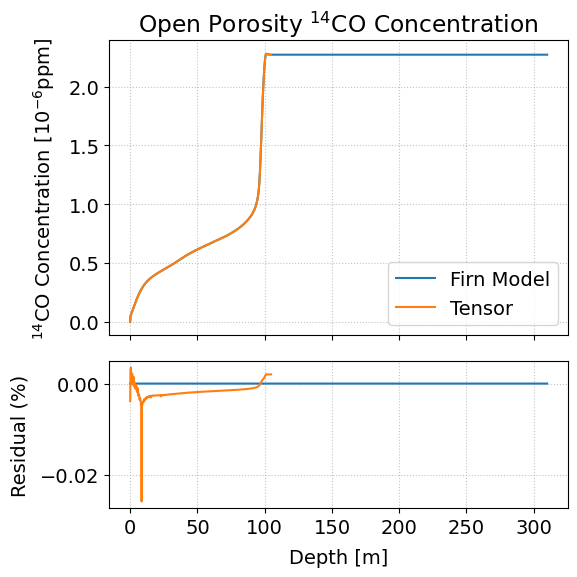

In [103]:
fig, axes = plt.subplots(2,1, figsize=(6,6), tight_layout=True, sharex = True, sharey=False, height_ratios=[2,1])

rel = c_gases[:,1:]@Res
axes[0].plot(DC.z_D, c_gases[:,1:]@Res, label='Firn Model')
axes[1].plot(DC.z_D, ((c_gases[:,1:]@Res)/(c_gases[:,1:]@Res) - 1)*100, label='Firn Model')
if True:
    axes[0].plot(DC.z_D[:DC.Q], P[:p_end] @ A_open_const @ Res, label='Tensor')
    axes[1].plot(DC.z_D[:DC.Q], ((P[:p_end] @ A_open_const @ Res)/rel[:DC.Q]-1)*100, label='Tensor')
if not const:
    axes[0].plot(DC.z_D[:DC.Q], np.einsum('fptr, p, t, r -> f', A_open, P[:p_end], phi[t_start-(D_t.shape[-1]//t_ratio)-2:], Res, optimize=True), label='Tensor')
    axes[1].plot(DC.z_D[1:DC.Q], (np.einsum('fptr, p, t, r -> f', A_open, P[:p_end], phi[t_start-(D_t.shape[-1]//t_ratio)-2:], Res, optimize=True)[1:]/rel[1:DC.Q]-1)*100, label='Tensor')
axes[0].legend()

axes[0].set(
    ylabel=r'$^{14}$CO Concentration [$10^{-6}$ppm]',
    title=r'Open Porosity $^{14}$CO Concentration',
)

axes[1].set(
    ylabel='Residual (%)',
    xlabel='Depth [m]',
)

### Closed Porosity (from Grains)

$$\vec{c}^{\text{closed}}_{f} = \sum_{p,t,r} [\hat{A}^{\text{leak}} + \hat{A}^{\text{trap}}]_{f,p,t,r}\vec{P}_p\vec{\phi}_{t}\vec{R}_r + \sum_{t}\hat{A}^{\text{atm}}_{f,t}\vec{C}^{\text{atm}}_{t}$$

$$\hat{A}^{\text{leak}}_{f,p,t,r} = e^{\lambda t_A}dt_A([\sum_{t'=0}^{-t_A}\frac{s_c(z_{a+t'})}{s(z_{a+t'})}\vec{l}_r^{t'}(1-\vec{l}_r^{dt'})] \hat{\delta}_{f,a-t_A})\cdot \hat{\delta}_{a,p} \cdot \hat{\delta}_{t_A,t}$$

$\hat{A}^{\text{leak}}_{f,p,t,r}$ - 

$t'$ - leak time (relative to production)

In [87]:
dt1 = DC.dt_A
t1 = np.arange(A_end)*DC.dt_A
i = np.arange(A_end)
j = np.arange(len(t1))
sc_frac = np.interp(DC.z_A[:A_end], DC.z_grid, DC.s_closed/DC.s.clip(min=1e-20))
sc_cast = (sc_frac[(i[:,None]+j[None,:]).clip(max=A_end-1)]*(i[:,None]+j[None,:]<=A_end-1))
#axis0 - production depth (p)
#axis1 - grain time (t2)

t = np.arange(A_end)-A_end

closed_in = np.cumsum(
    sc_cast[:,:,None] * (1-L[None,None,:])**t1[None,:,None],
    axis=1
)[:,::-1,:] * (1-(1-L)**dt1)[None,None,:] * np.exp(DC.lambd * t * DC.dt_A)[None,:,None] * DC.dt_A
#axis0 - Leakage rate (L)
#axis1 - production depth (p)
#axis2 - production time (t1)
closed_in.shape

(6388, 6388, 2)

In [88]:
if True:
    t = np.arange(A_end)-A_end
    A_closed_const = np.zeros((f_end+1, A_end, len(L)))
    for i in tqdm(t):
        A_closed_const[:,:i,:] += delta_fAend[:,-i:,None] * closed_in[None,:i,i,:]
    A_closed_const = delta_Ap[:A_end,:p_end].T @ A_closed_const
    A_closed_const.shape

100%|██████████████████████████████████████████████████████████████████████████████| 6388/6388 [00:34<00:00, 183.44it/s]


In [89]:
if not const:
    t = np.arange(A_end)-A_end
    A_closed = np.zeros((f_end+1, A_end, len(t_CR[t_start:]), len(L)))

    t_ratio = int(dt_CR/DC.dt_A)

    # for efficiency, we manually perform the dot product with delta_At
    for i in tqdm(t): # integration timesteps, from formation of first ice (in range) to present, centered on left side of bin
        j = i//t_ratio # bin index of current time in CR timescale resolution
        k = (i%t_ratio+0.5)/t_ratio # integration time bin center's fraction of the way between CR time grid points
        # scale new 14CO by leak&decay fraction, then interpolate from accumulation depth + remaining time to final depth grid
        x = delta_fAend[:,-i:,None] * closed_in[None,:i,i,:]
        A_closed[:,:i,j,:] += x * (1-k) # interpolation contribution from CR time j
        A_closed[:,:i,j+1,:] += x * k # interpolation contribution from CR time j+1
    A_closed = np.einsum('fAtr, Ap -> fptr', A_closed, delta_Ap[:A_end,:p_end], optimize=True)
    A_closed.shape

100%|███████████████████████████████████████████████████████████████████████████████| 6388/6388 [02:58<00:00, 35.75it/s]


[Text(0, 0.5, 'Residual (%)'), Text(0.5, 0, 'Depth [m]')]

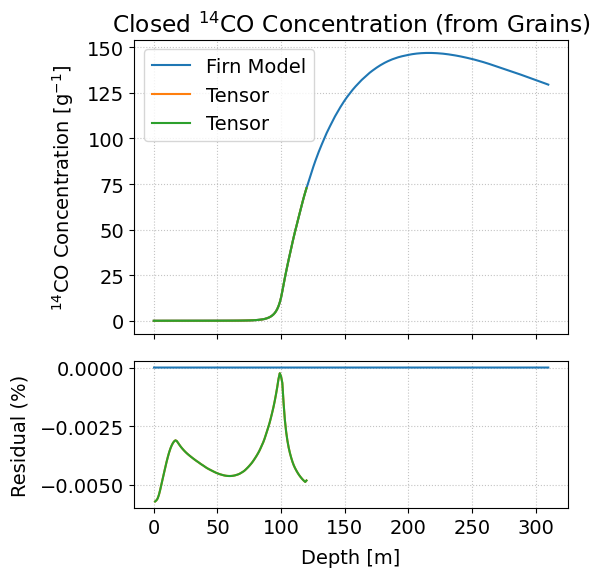

In [90]:
fig, axes = plt.subplots(2,1, figsize=(6,6), tight_layout=True, sharex = True, sharey=False, height_ratios=[2,1])

rel = np.interp(z_f_end, DC.z_grid, cumuleak_closed[:,0]@Res)
axes[0].plot(DC.z_grid, cumuleak_closed[:,0]@Res, label='Firn Model')
axes[1].plot(DC.z_grid[1:], (cumuleak_closed[1:,0]@Res / (cumuleak_closed[1:,0]@Res) -1)*100, label='Firn Model')
if True:
    axes[0].plot(z_f_end, P[:p_end] @ A_closed_const @ Res, label='Tensor')
    axes[1].plot(z_f_end[1:], ((P[:p_end] @ A_closed_const @ Res)[1:]/rel[1:] -1)*100, label='Tensor')
if not const:
    axes[0].plot(z_f_end, np.einsum('fptr, p, t, r -> f', A_closed, P[:p_end], phi[t_start:], Res, optimize=True), label='Tensor')
    axes[1].plot(z_f_end[1:], (np.einsum('fptr, p, t, r -> f', A_closed, P[:p_end], phi[t_start:], Res, optimize=True)[1:]/rel[1:] -1)*100, label='Tensor')
    
axes[0].legend()

axes[0].set(
    ylabel=r'$^{14}$CO Concentration [g$^{-1}$]',
    title=r'Closed $^{14}$CO Concentration (from Grains)',
)

axes[1].set(
    ylabel='Residual (%)',
    xlabel='Depth [m]',
    #ylim=(-0.002,0.002),
)

### Closed Porosity (from Open Atm)

$$\hat{A}^{\text{atm}}_{f,t} = U_{ppm\rightarrow g}(z_f)\hat{\delta}_{f,a}\cdot(\sum_{t'=0}^{a}\frac{\text{tr}_{a-t'}}{\sum_{t''}^{a} \text{tr}_{t''}}e^{-\lambda t'} \hat{\mathcal{A}}^{\text{atm}}_{a-t',t_A-t'}) \cdot \hat{\delta}_{t_A,t}$$

$\hat{A}^{\text{atm}}$ - 

$\hat{\mathcal{A}}^{\text{atm}}_{a,t_A} = \hat{\delta}_{a-t',d}\cdot[\sum_{t_D=0}^{dt_A} D^{t_D} \frac{dt_D}{dt_A}]_{d,d'}\cdot D^{-t_A-t'}_{d',0}\,dt_A$

In [91]:
if DC.z_D[0]>0:
    delta_Ad = interp_mat(DC.z_A[:,None],np.array([0,*DC.z_D])[None,:])[:,1:]
else:
    delta_Ad = interp_mat(DC.z_A[:,None],DC.z_D[None,:])
A_open_atm_A = delta_Ad[:A_end,:DC.Q] @ (np.sum(cum_mat_prod(DC.D,int(DC.dt_A/DC.dt_D)), axis=0)[:,0] @ D_t[:,:,::-1])
#axis0 - final depth (f)
#axis1 - atmospheric time (t_atm)
A_open_atm_A.shape

100%|█████████████████████████████████████████████████████████████████████████████████| 49/49 [00:00<00:00, 1524.41it/s]


(6388, 2000)

In [92]:
A_trap_atm = np.zeros((A_end, A_end+N_D))

trap_A = np.interp(DC.z_A[:A_end], DC.z_grid, DC.trapping_t)
trap_sum = np.cumsum(trap_A*DC.dt_A)

atm_start2 = -int((A_end+N_D)*DC.dt_A/dt_atm)

dt1 = DC.dt_A
for t1 in tqdm(range(A_end)):
    A_trap_atm[t1:,t1:t1+N_D] += np.exp(-DC.lambd*t1*dt1) * trap_A[:A_end-t1,None]/trap_sum[t1:,None] * A_open_atm_A[:A_end-t1,:] * dt1
A_trap_atm *= np.interp(DC.z_A[:A_end], DC.z_grid, DC.ppm_to_gram_cl)[:,None]
A_trap_atm = delta_fAend @ A_trap_atm
#A_trap_atm[:,A_end-1] += np.sum(A_trap_atm[:,len(DC.z_A):],axis=-1)
A_trap_atm = A_trap_atm @ delta_Atatm[-A_end-N_D:,atm_start2:]
#axis0 - accumulation depth (a)
#axis1 - production time (t1)
A_trap_atm.shape

100%|███████████████████████████████████████████████████████████████████████████████| 6388/6388 [02:27<00:00, 43.35it/s]


(121, 419)

[Text(0, 0.5, 'Residual (%)'), Text(0.5, 0, 'Depth [m]')]

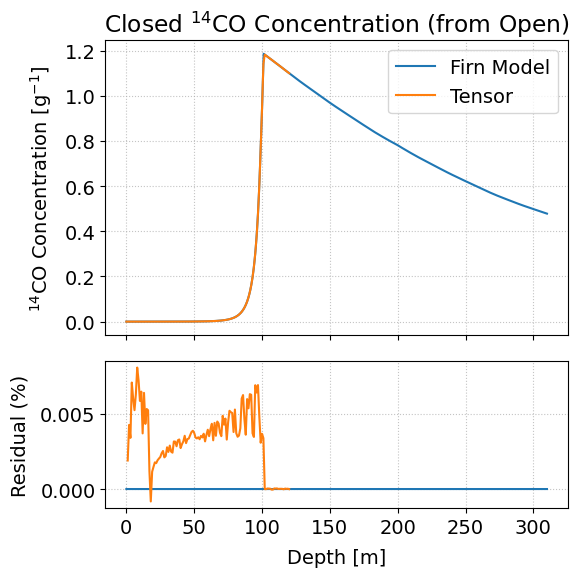

In [95]:
fig, axes = plt.subplots(2,1, figsize=(6,6), tight_layout=True, sharex = True, sharey=False, height_ratios=[2,1])

rel = np.interp(z_f_end, DC.z_grid, C14_closed_atm)
axes[0].plot(DC.z_grid, C14_closed_atm, label='Firn Model')
axes[1].plot(DC.z_grid, (C14_closed_atm/C14_closed_atm - 1)*100, label='Firn Model')

axes[0].plot(z_f_end, A_trap_atm @ gas_history[atm_start2:], label='Tensor')
axes[1].plot(z_f_end[1:], ((A_trap_atm @ gas_history[atm_start2:])[1:]/rel[1:]-1)*100, label='Tensor')

axes[0].legend()

axes[0].set(
    ylabel=r'$^{14}$CO Concentration [g$^{-1}$]',
    title=r'Closed $^{14}$CO Concentration (from Open)',
)

axes[1].set(
    ylabel='Residual (%)',
    xlabel='Depth [m]',
)

### Closed Porosity (from Open In Situ)

$$\hat{A}^{\text{trap}}_{f,p,t,r} = U_{ppm\rightarrow g}(z_f)\hat{\delta}_{f,a}\cdot(\sum_{t'=0}^{a}\frac{\text{tr}_{a-t'}}{\sum^a_{t''} \text{tr}_{t''}}e^{-\lambda t'}\hat{\mathcal{A}}^{\text{open}}_{a-t',p,t_A,r}) \cdot \hat{\delta}_{t_A+t',t}$$

$\hat{A}^{\text{trap}}$ - 

$\hat{\mathcal{A}}^{\text{open}}_{a,p,t_A,r} = \hat{\delta}_{a,d}\cdot[\sum_{t''=0}^{\text{age}_{co}} \hat{\mathcal{D}}_{d,a'+t'',-t_A-t''} \vec{\Lambda}_r^{t''}(1-\vec{l}_r^{dt''})]dt_A\cdot \hat{\delta}_{a',p}$

$t'$ - time in closed grain after getting trapped

Note: I think $U_{ppm\rightarrow g}$ should be applied at trapping depth ($z_{a-t'}$), but in the firn model it is applied at final depth ($z_{f}$)

In [96]:
A_trap_const = np.zeros((A_end, p_end, len(L)))#, len(t1)+N_op))

trap_A = np.interp(DC.z_A[:A_end], DC.z_grid, DC.trapping_t)
trap_sum = np.cumsum(trap_A*DC.dt_A)

A_open_const_A = np.einsum('ad, dpr -> apr', delta_Ad[:A_end,:DC.Q], A_open_const, optimize=True)

dt1 = DC.dt_A
for t1 in tqdm(range(A_end)):
    A_trap_const[t1:,:,:] += np.exp(-DC.lambd*t1*dt1) * trap_A[:A_end-t1,None,None]/trap_sum[t1:,None,None] * A_open_const_A[:A_end-t1] * dt1
A_trap_const *= np.interp(DC.z_A[:A_end], DC.z_grid, DC.ppm_to_gram_cl)[:,None,None]
A_trap_const = np.einsum('fa, apr -> fpr', delta_fAend, A_trap_const, optimize=True)
#axis0 - Leakage rate (L)
#axis1 - accumulation depth (a)
#axis2 - production depth (p)
#axis3 - production time (t1)
A_trap_const.shape

100%|██████████████████████████████████████████████████████████████████████████████| 6388/6388 [00:09<00:00, 672.89it/s]


(121, 83, 2)

In [113]:
if not const:
    t_ratio = int(dt_CR/DC.dt_A)
    CR_end = int(A_end/t_ratio)+1+A_open.shape[-2]
    A_trap = np.zeros((A_end, p_end, CR_end, len(L)))

    trap_A = np.interp(DC.z_A[:A_end], DC.z_grid, DC.trapping_t)
    trap_sum = np.cumsum(trap_A*DC.dt_A)

    A_open_A = np.einsum('ad, dptr -> aptr', delta_Ad[:A_end,:DC.Q], A_open, optimize=True)


    dt1 = DC.dt_A
    for t1 in tqdm(range(A_end)):
        j = int(t1/t_ratio) # bin index of current time in CR timescale resolution
        k = (t1%t_ratio)/t_ratio # integration time bin center's fraction of the way between CR time grid points
        x = np.exp(-DC.lambd*t1*dt1) * (trap_A[:A_end-t1]/trap_sum[t1:])[:,None,None,None] * A_open_A[:A_end-t1,:,:,:] * dt1
        A_trap[t1:,:,-j-A_open_A.shape[-2]:CR_end-j,:] += x * (1-k)
        A_trap[t1:,:,-j-1-A_open_A.shape[-2]:-j-1,:] += x * k
    A_trap_atm *= np.interp(DC.z_A[:A_end], DC.z_grid, DC.ppm_to_gram_cl)[:,None]
    A_trap_atm = delta_fAend @ A_trap_atm
    #A_trap_atm[:,A_end-1] += np.sum(A_trap_atm[:,len(DC.z_A):],axis=-1)
    #axis0 - accumulation depth (a)
    #axis1 - production time (t1)
    A_trap_atm.shape

[Text(0, 0.5, 'Residual (%)'), Text(0.5, 0, 'Depth [m]')]

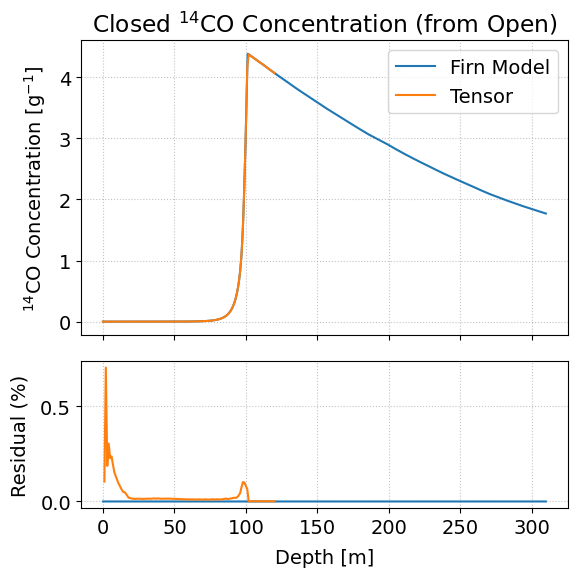

In [114]:
fig, axes = plt.subplots(2,1, figsize=(6,6), tight_layout=True, sharex = True, sharey=False, height_ratios=[2,1])

rel = np.interp(z_f_end, DC.z_D, C14_closed[:,0]@Res)
axes[0].plot(DC.z_D, C14_closed[:,0]@Res, label='Firn Model')
axes[1].plot(DC.z_D, ((C14_closed[:,0]@Res)/(C14_closed[:,0]@Res) - 1)*100, label='Firn Model')
if True:
    axes[0].plot(z_f_end, P[:p_end] @ A_trap_const @ Res, label='Tensor')
    axes[1].plot(z_f_end[1:], ((P[:p_end] @ A_trap_const @ Res)[1:]/rel[1:]-1)*100, label='Tensor')
if not const:
    axes[0].plot(z_f_end, np.einsum('fptr, p, t, r -> f', P[:p_end], phi[-CR_end:], Res), label='Tensor')
    axes[0].plot(z_f_end, np.einsum('fptr, p, t, r -> f', P[:p_end], phi[-CR_end:], Res), label='Tensor')
axes[0].legend()

axes[0].set(
    ylabel=r'$^{14}$CO Concentration [g$^{-1}$]',
    title=r'Closed $^{14}$CO Concentration (from Open)',
)

axes[1].set(
    ylabel='Residual (%)',
    xlabel='Depth [m]',
)

### Total Firn Tensor ($\hat{A}^{\text{firn}}$)

$$\vec{c}^{pred}_s = \sum_{t',p} \hat{A}_{s,p,t'}\vec{P}_p\vec{\phi}_{t'} + \sum_{t}\hat{A}^{atm}_{s,t}\vec{C}_{t}^{atm}$$

$$\hat{A}_{s,p,t,r} = \hat{S}_{s,f}\cdot[\hat{A}^{grains}+\hat{A}^{closed}+\hat{A}^{trap}]_{f,p,t,r}$$

$$\hat{A}^{atm}_{s,t'} = \hat{S}_{s,f}\cdot \hat{A}^{atm}_{f,t}$$

$$\Sigma^{pred}_{ss'} = (\hat{A}\vec{\phi}\vec{R})_{s,p}\Sigma^{\vec{P}}_{p,p'}(\hat{A}\vec{\phi}\vec{R})^T_{p',s'} + (\hat{A}^{atm})_{s,t}\Sigma^{atm}_{t,t'}(\hat{A}^{atm})^T_{t',s'}$$

In [97]:
if True:
    A_const = A_grains_const + A_closed_const + A_trap_const

In [98]:
if not const:
    A_profile = A_grains + A_closed

[Text(0, 0.5, '% Relative to Matlab'), Text(0.5, 0, 'Depth [m]')]

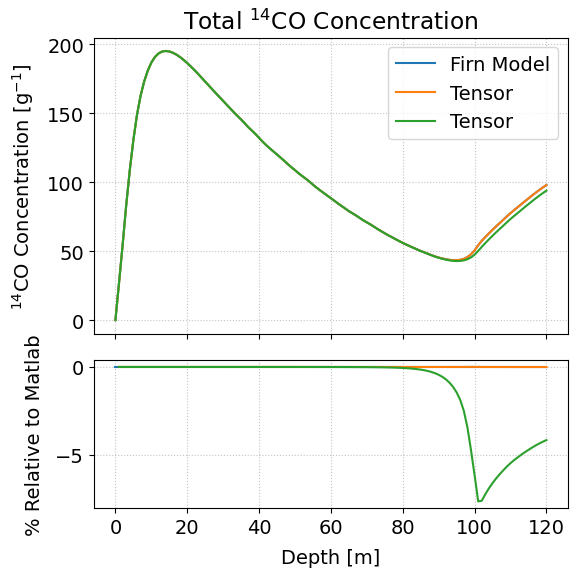

In [99]:
fig, axes = plt.subplots(2,1, figsize=(6,6), tight_layout=True, sharex = True, sharey=False, height_ratios=[2,1])

rel = np.interp(z_f_end, DC.z_grid, (grains[:,0] + cumuleak_closed[:,0] + C14_closed[:,0])@Res + C14_closed_atm)
axes[0].plot(z_f_end, rel, label='Firn Model')
axes[1].plot(z_f_end, (rel/rel - 1)*100, label='Firn Model')

axes[0].plot(z_f_end, P[:p_end] @ A_const @ Res + A_trap_atm @ gas_history[atm_start2:], label='Tensor')
axes[1].plot(z_f_end[1:], ((P[:p_end] @ A_const @ Res + A_trap_atm @ gas_history[atm_start2:])[1:]/rel[1:]-1)*100, label='Tensor')

if not const:
    axes[0].plot(z_f_end, np.einsum('fptr, p, t, r -> f', A_profile, P[:p_end], phi[t_start:], Res) + A_trap_atm @ gas_history[atm_start2:], label='Tensor')
    axes[1].plot(z_f_end[1:], ((np.einsum('fptr, p, t, r -> f', A_profile, P[:p_end], phi[t_start:], Res) + A_trap_atm @ gas_history[atm_start2:])[1:]/rel[1:]-1)*100, label='Tensor')

axes[0].legend()

axes[0].set(
    ylabel=r'$^{14}$CO Concentration [g$^{-1}$]',
    title=r'Total $^{14}$CO Concentration',
)

axes[1].set(
    ylabel='% Relative to Matlab',
    xlabel='Depth [m]',
)

## Dome C, below close-off (Solid Ice)

$$\hat{A}_{f,p,t,r} = \begin{cases}
\hat{A}_{f,p,t,r} & f\leq f_{co}, p\leq p_{co}\\
\hat{A}_{f_{co},p,t',r}\cdot\hat{\delta}_{t',t+\Delta t}e^{-\lambda\Delta t} & f>f_{co}, p\leq p_{co}\\
[e^{\lambda t_A}dt_A\, \hat{\delta}_{f,a-t_A}\cdot \hat{\delta}_{a,p}] \cdot \hat{\delta}_{t_A,t} & f>f_{co}, p> p_{co}\\
0 & \text{else}
\end{cases}$$

$\Delta t = \text{age}(z_f)-\text{age}(z_{co})$

Works out much easier if $f$ is evenly spaced in ice age (at least below close-off depth)

In [100]:
A_ext = np.zeros((len(z_f_DC), len(Prop_DC.h), len(L)))

A_ext[:f_end,:p_end] = A_const[:f_end]
A_ext[f_end:,:p_end] = A_const[-1:] * np.exp(-DC.lambd * (DC.z_to_age(z_f_DC[f_end:]) - DC.age_A[A_end-1]))[:,None,None]

t = -np.arange(len(DC.z_A)-A_end+1)-1 # integration timesteps, from formation of first ice (in range) to present, centered on left side of bin
A_ext_const = np.zeros((len(z_f_DC), len(DC.z_A)-A_end+1, len(L)))
for i in tqdm(t): # step through integration time (i)
    # scale new 14CO by leak&decay fraction, then interpolate from accumulation depth + remaining time to final depth grid
    A_ext_const[f_end:,:i,:] += delta_fA[f_end:,A_end-1-i:,None] * np.exp(DC.lambd*i*DC.dt_A) * DC.dt_A
# interpolate from production depths to accumulation depths
A_ext_const = delta_Ap[A_end-1:].T @ A_ext_const

A_ext += A_ext_const

100%|█████████████████████████████████████████████████████████████████████████████| 13700/13700 [04:46<00:00, 47.75it/s]


In [101]:
A_atm = np.zeros((len(z_f_DC), len(t_atm)))

A_atm[:f_end, atm_start2:] = A_trap_atm[:f_end]
A_atm[f_end:, atm_start2:] = A_trap_atm[-1] * np.exp(-DC.lambd * (DC.z_to_age(z_f_DC[f_end:]) - DC.age_A[A_end-1]))[:,None]

In [ ]:
if not const:
    A_full = np.zeros((len(z_f_DC), len(Prop_DC.h), len(t_CR), len(L)))

    A_full[:f_end, :p_end, t_start:] = A_profile[:f_end]
    A_full[f_end:,:p_end, t_start:] = A_profile[-1:] * np.exp(-DC.lambd * (DC.z_to_age(z_f_DC[f_end:]) - DC.age_A[A_end-1]))[:,None,None,None]

    t = -np.arange(len(DC.z_A)-A_end+1)-1 # integration timesteps, from formation of first ice (in range) to present, centered on left side of bin
    A_new = np.zeros((len(z_f_DC), len(DC.z_A)-A_end+1, len(t_CR), len(L)))
    for i in tqdm(t): # step through integration time (i)
        j = i//t_ratio # bin index of current time in CR timescale resolution
        k = (i%t_ratio+0.5)/t_ratio # integration time bin center's fraction of the way between CR time grid points
        # scale new 14CO by leak&decay fraction, then interpolate from accumulation depth + remaining time to final depth grid
        x = delta_fA[f_end:,A_end-1-i:,None] * np.exp(DC.lambd*i*DC.dt_A) * DC.dt_A
        A_new[f_end:,:i,j,:] += x * (1-k) # interpolation contribution from CR time j
        A_new[f_end:,:i,j+1,:] += x * k # interpolation contribution from CR time j+1
    # interpolate from production depths to accumulation depths
    A_new = (delta_Ap[A_end-1:].T @ A_new.T).T

    A_full += A_new

100%|█████████████████████████████████████████████████████████████████████████████| 13700/13700 [27:45<00:00,  8.23it/s]


In [ ]:
fig, axes = plt.subplots(2,1, figsize=(6,6), tight_layout=True, sharex = True, sharey=False, height_ratios=[2,1])

rel = np.interp(z_f_DC, DC.z_grid, (grains[:,0] + cumuleak_closed[:,0])@Res) + np.interp(z_f_DC, DC.z_D, C14_closed[:,0]@Res + C14_closed_atm)
axes[0].plot(z_f_DC, rel, label='Firn Model')
axes[1].plot(z_f_DC, (rel/rel - 1)*100, label='Firn Model')

axes[0].plot(z_f_DC, P @ A_ext @ Res + A_atm @ gas_history, label='Tensor')
axes[1].plot(z_f_DC[1:-1], ((P @ A_ext @ Res + A_atm @ gas_history)[1:-1]/rel[1:-1]-1)*100, label='Tensor')

if not const:
    axes[0].plot(z_f_DC, np.einsum('fptr, p, t, r -> f', A_full, P, phi, Res) + A_atm @ gas_history, label='Tensor')
    axes[0].plot(z_f_DC, ((np.einsum('fptr, p, t, r -> f', A_full, P, phi, Res) + A_atm @ gas_history)[1:-1]/rel[1:-1]-1)*100, label='Tensor')

axes[0].legend()

axes[0].set(
    ylabel=r'$^{14}$CO Concentration [g$^{-1}$]',
    title=r'Total $^{14}$CO Concentration',
)

axes[1].set(
    ylabel='% Relative to Matlab',
    xlabel='Depth [m]',
)

## Sample Average

In [ ]:
S_mat = bin_average_mat(DC.z_samp_bins[0,:,None],DC.z_samp_bins[1,:,None],DC.z_grid[None,:],np.array([0,*np.diff(DC.z_grid)])[None,:])

In [ ]:
A_const_samp = (A_ext.T @ S_mat.T).T
A_full_samp = (A_full.T @ S_mat.T).T

# $^{14}$CO Model

## Predicted $^{14}$CO ($\vec{c}^{\text{pred}}$) & Uncertainty ($\Sigma^{\text{pred}}$)

$$\vec{c}^{pred}_s = \sum_{t',p} \hat{A}_{s,p,t'}\vec{P}_p\vec{\phi}_{t'} + \sum_{t}\hat{A}^{atm}_{s,t}\vec{C}_{t}^{atm}$$

$$\Sigma^{pred}_{ss'} = (\hat{A}\vec{\phi}\vec{R})_{s,p}\Sigma^{\vec{P}}_{p,p'}(\hat{A}\vec{\phi}\vec{R})^T_{p',s'} + (\hat{A}^{atm})_{s,t}\Sigma^{atm}_{t,t'}(\hat{A}^{atm})^T_{t',s'}$$

## Parameters ($\vec{\theta}$), Parameter Space ($\Theta$), & Priors ($p$)

## Simulated Sample ($\vec{c}^{\text{samp}}$) & Uncertainty ($\Sigma^{\text{samp}}$)

## Sensitivity

# Test Statistics

## Likelihood ($L$)

$$\log L(\Delta\vec{c},\Sigma) = -\frac{1}{2}\Delta\vec{c}\Sigma\Delta\vec{c}^T - \frac{1}{2}\log|2\pi\Sigma|$$
where $\Delta \vec{c} = \vec{c}^{\text{exp}}-\vec{c}^{\text{pred}}$ and $\Sigma = \Sigma^{\text{exp}} + \Sigma^{\text{pred}}$

## Evidence ($Z$)

$$Z(\vec{c}^{\text{exp}}) = \int L(\vec{c}^{\text{exp}}|\vec{\theta}) p(\vec{\theta}) d\vec{\theta}$$

## P-Value ($p$)

$$p(Z) = \text{prob}(Z'>Z)$$

where $Z'=Z(\vec{c}^{\text{samp}})$ for randomly drawn $\vec{c}^{\text{samp}}$

## Posterior ($P$)

$$P(\vec{\theta}|\vec{c}^{\text{exp}}) = \frac{L(\vec{c}^{\text{exp}}|\vec{\theta}) p(\vec{\theta})}{Z(\vec{c}^{\text{exp}})}$$

Note: Because $P$ is a probability density, its value depends on the projection we use for our parameter space

# Analysis

## Null Hypothesis Test ($\sigma^{\text{null}}$)

## Best Fit Parameters ($\hat{\theta}$) & Uncertainty ($\Sigma^{\hat{\theta}}$)

Note: Because $P$ is a probability density, the best fit depends on the projection we use for our parameter space

### Best-Fit, Constant $\vec{\phi}$

### Best-Fit, Variable $\vec{\phi}$

## Posterior Contours ($\Theta(P>X\%)$??)

Note: Because $P$ is a probability density, the contours depend on the projection we use for our parameter space

### $\vec{f}$ confidence interval, constant/best-fit $\vec{\phi}$, marginalize the rest

### $\vec{\phi}$ confidence interval, marginalize the rest